# Top 10 Products

## About the Dataset

The **Sample Superstore dataset** is a sales dataset containing information about products, customers, sales transactions, discounts, and profits. It contains **9,994 records and 13 columns** before data cleaning. The main columns include Ship Mode, Segment, Country, City, State, Region, Category, Sub-Category, Sales, Quantity, Discount, and Profit.

The dataset was checked for missing values and duplicate records. No missing values were found, while **17 duplicate records** were removed, leaving **9,977 records** for analysis.

This project focuses on analyzing the performance of different **Sub-Categories** using sales, profit, quantity, discount, average sales, average profit, profit margin, and other business metrics. Graphs and visualizations are used to identify the top-performing sub-categories and understand the relationship between sales and profitability.

The dataset is useful for practicing **data cleaning, exploratory data analysis, business analysis, and data visualization** using Python, Pandas, Matplotlib, and Seaborn.


In [1]:
# ============================================================
# SAMPLE SUPERSTORE - COMPLETE SALES ANALYSIS
# ============================================================

# Install if required:
# pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

file_path = "SampleSuperstore(1).csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Loaded Successfully
Shape: (9994, 13)

Columns:
['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']


In [2]:
# ------------------------------------------------------------
# 2. BASIC DATA CLEANING
# ------------------------------------------------------------

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate records
print("\nDuplicate Records:", df.duplicated().sum())

# Remove duplicate records
df = df.drop_duplicates()

print("\nShape after removing duplicates:", df.shape)


Missing Values:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicate Records: 17

Shape after removing duplicates: (9977, 13)


In [4]:
# ------------------------------------------------------------
# 3. BASIC DATA INFORMATION
# ------------------------------------------------------------

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())



Data Types:
Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

Statistical Summary:
        Postal Code         Sales     Quantity     Discount      Profit
count   9977.000000   9977.000000  9977.000000  9977.000000  9977.00000
mean   55154.964117    230.148902     3.790719     0.156278    28.69013
std    32058.266816    623.721409     2.226657     0.206455   234.45784
min     1040.000000      0.444000     1.000000     0.000000 -6599.97800
25%    23223.000000     17.300000     2.000000     0.000000     1.72620
50%    55901.000000     54.816000     3.000000     0.200000     8.67100
75%    90008.000000    209.970000     5.000000     0.200000    29.37200
max    99301.000000  22638.480000    14.000000     0.800000  83

In [3]:
# ------------------------------------------------------------
# 4. KEY PERFORMANCE INDICATORS
# ------------------------------------------------------------

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()

average_sales = df["Sales"].mean()
average_profit = df["Profit"].mean()
average_discount = df["Discount"].mean()

profit_margin = (total_profit / total_sales) * 100

print("\n================ KPI ANALYSIS ================")

print(f"Total Sales      : ${total_sales:,.2f}")
print(f"Total Profit     : ${total_profit:,.2f}")
print(f"Total Quantity   : {total_quantity:,}")
print(f"Average Sales    : ${average_sales:,.2f}")
print(f"Average Profit   : ${average_profit:,.2f}")
print(f"Average Discount : {average_discount:.2%}")
print(f"Profit Margin    : {profit_margin:.2f}%")



================ KPI ANALYSIS ================
Total Sales      : $2,296,195.59
Total Profit     : $286,241.42
Total Quantity   : 37,820
Average Sales    : $230.15
Average Profit   : $28.69
Average Discount : 15.63%
Profit Margin    : 12.47%



Sales by Category:
Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64


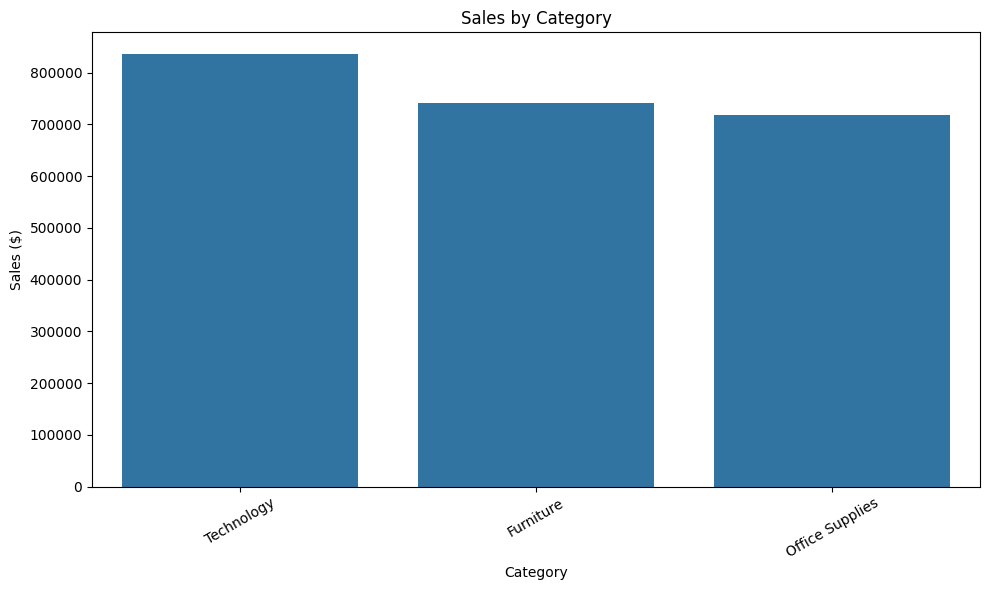

In [3]:
# ------------------------------------------------------------
# 5. SALES BY CATEGORY
# ------------------------------------------------------------

category_sales = df.groupby("Category")["Sales"].sum().sort_values(
    ascending=False
)

print("\nSales by Category:")
print(category_sales)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Profit by Category:
Category
Technology         145454.9481
Office Supplies    122364.6608
Furniture           18421.8137
Name: Profit, dtype: float64


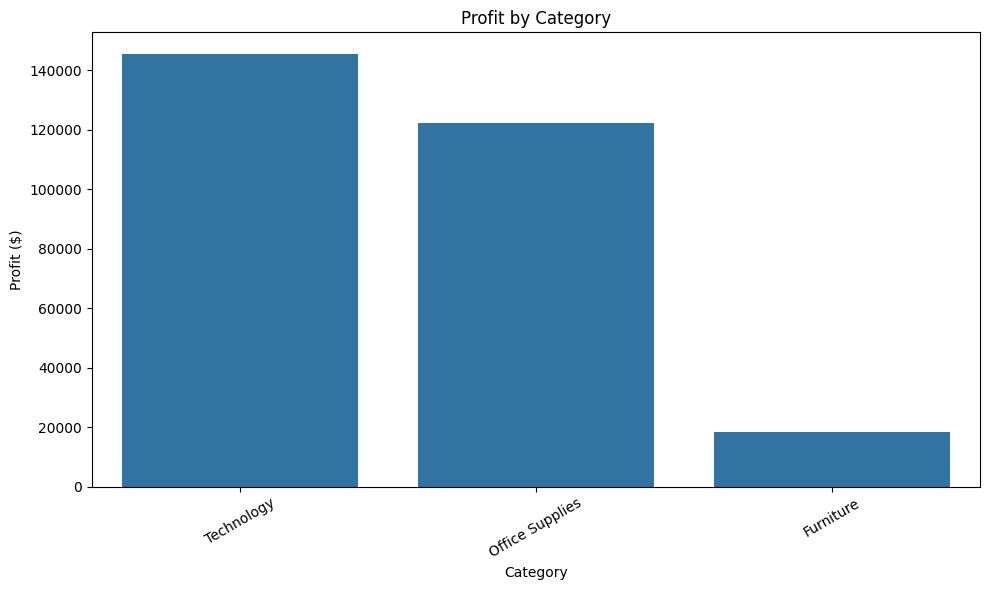

In [5]:
# ------------------------------------------------------------
# 6. PROFIT BY CATEGORY
# ------------------------------------------------------------

category_profit = df.groupby("Category")["Profit"].sum().sort_values(
    ascending=False
)

print("\nProfit by Category:")
print(category_profit)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_profit.index,
    y=category_profit.values
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Sales by Sub-Category:
Sub-Category
Phones         330007.0540
Chairs         327777.7610
Storage        223843.6080
Tables         206965.5320
Binders        203409.1690
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91683.0240
Paper           78224.1420
Supplies        46673.5380
Art             27107.0320
Envelopes       16476.4020
Labels          12444.9120
Fasteners        3024.2800
Name: Sales, dtype: float64


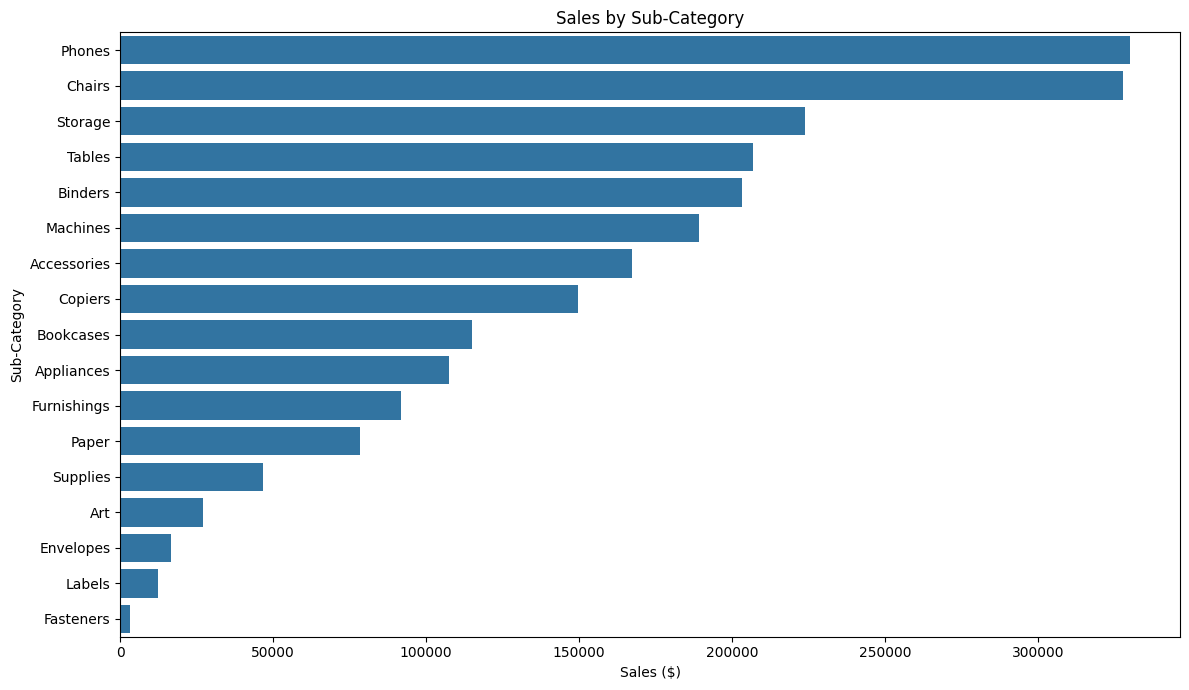

In [4]:
# ------------------------------------------------------------
# 7. SALES BY SUB-CATEGORY
# ------------------------------------------------------------

subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(
    ascending=False
)

print("\nSales by Sub-Category:")
print(subcategory_sales)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=subcategory_sales.values,
    y=subcategory_sales.index
)

plt.title("Sales by Sub-Category")
plt.xlabel("Sales ($)")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()


Profit by Sub-Category:
Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          33944.2395
Binders        30228.0003
Chairs         26567.1278
Storage        21278.8264
Appliances     18138.0054
Furnishings    13052.7230
Envelopes       6964.1767
Art             6524.6118
Labels          5526.3820
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64


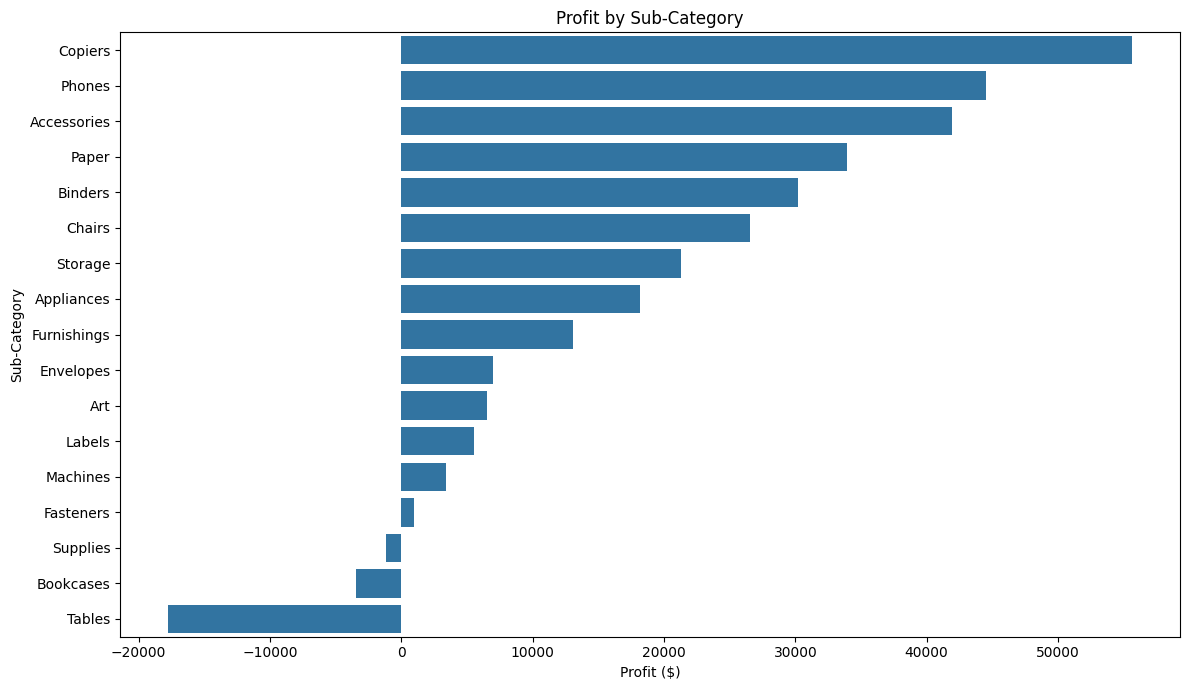

In [7]:
# ------------------------------------------------------------
# 8. PROFIT BY SUB-CATEGORY
# ------------------------------------------------------------

subcategory_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values(
    ascending=False
)

print("\nProfit by Sub-Category:")
print(subcategory_profit)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=subcategory_profit.values,
    y=subcategory_profit.index
)

plt.title("Profit by Sub-Category")
plt.xlabel("Profit ($)")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()


Sales by Region:
Region
West       725255.6365
East       678435.1960
Central    500782.8528
South      391721.9050
Name: Sales, dtype: float64


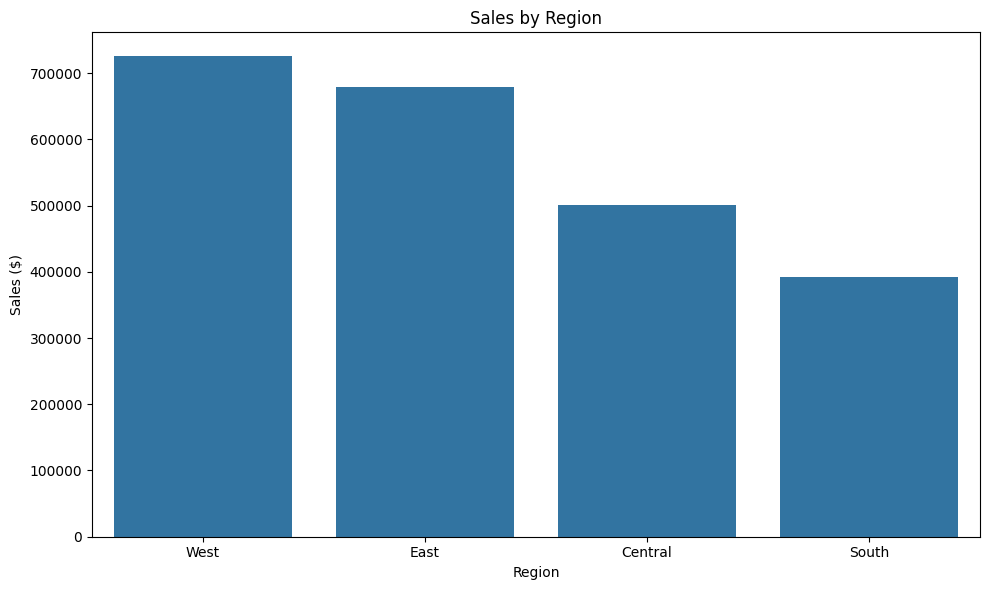

In [5]:
# ------------------------------------------------------------
# 9. REGION SALES
# ------------------------------------------------------------

region_sales = df.groupby("Region")["Sales"].sum().sort_values(
    ascending=False
)

print("\nSales by Region:")
print(region_sales)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.show()


Profit by Region:
Region
West       108329.8079
East        91506.3092
South       46749.4303
Central     39655.8752
Name: Profit, dtype: float64


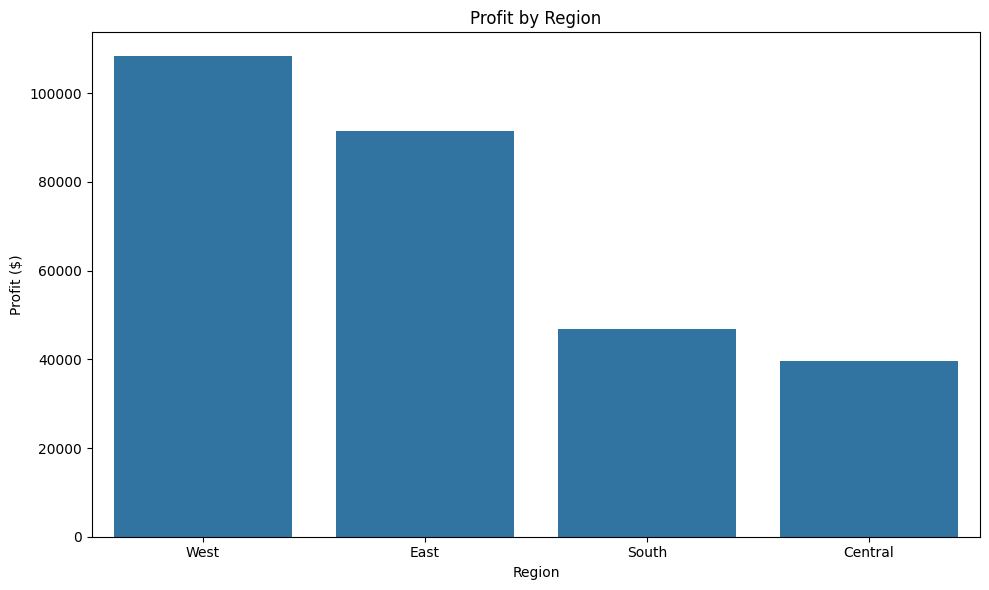

In [9]:
# ------------------------------------------------------------
# 10. REGION PROFIT
# ------------------------------------------------------------

region_profit = df.groupby("Region")["Profit"].sum().sort_values(
    ascending=False
)

print("\nProfit by Region:")
print(region_profit)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_profit.index,
    y=region_profit.values
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()


Sales by Segment:
Segment
Consumer       1.160833e+06
Corporate      7.060701e+05
Home Office    4.292927e+05
Name: Sales, dtype: float64


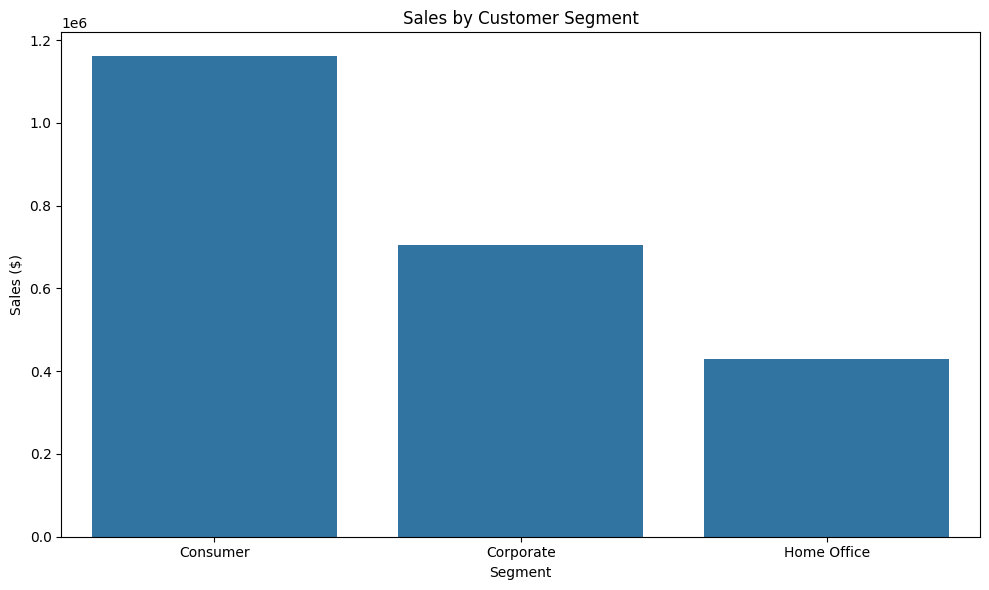

In [6]:
# ------------------------------------------------------------
# 11. SEGMENT SALES
# ------------------------------------------------------------

segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(
    ascending=False
)

print("\nSales by Segment:")
print(segment_sales)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.show()


Profit by Segment:
Segment
Consumer       134007.4413
Corporate       91954.9798
Home Office     60279.0015
Name: Profit, dtype: float64


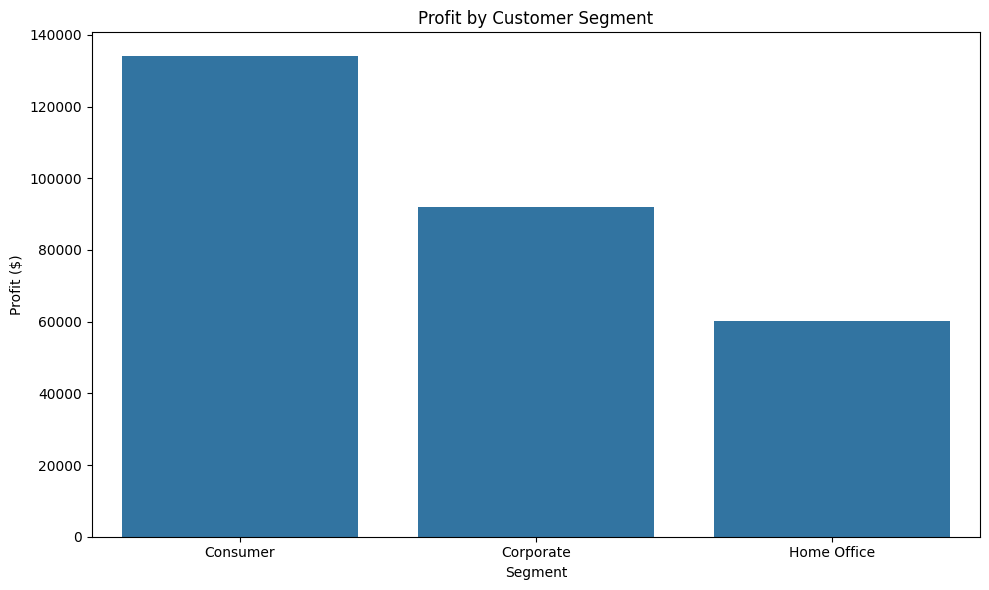

In [11]:
# ------------------------------------------------------------
# 12. SEGMENT PROFIT
# ------------------------------------------------------------

segment_profit = df.groupby("Segment")["Profit"].sum().sort_values(
    ascending=False
)

print("\nProfit by Segment:")
print(segment_profit)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_profit.index,
    y=segment_profit.values
)

plt.title("Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()


Sales by Ship Mode:
Ship Mode
Standard Class    1.357316e+06
Second Class      4.591770e+05
First Class       3.513805e+05
Same Day          1.283217e+05
Name: Sales, dtype: float64


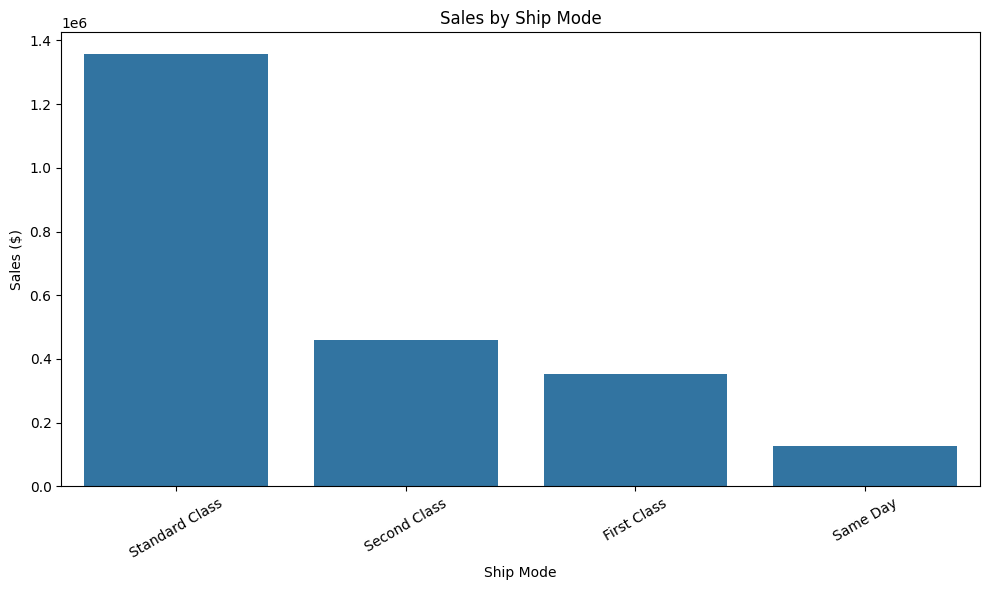

In [7]:
# ------------------------------------------------------------
# 13. SALES BY SHIP MODE
# ------------------------------------------------------------

ship_sales = df.groupby("Ship Mode")["Sales"].sum().sort_values(
    ascending=False
)

print("\nSales by Ship Mode:")
print(ship_sales)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=ship_sales.index,
    y=ship_sales.values
)

plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Sales ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

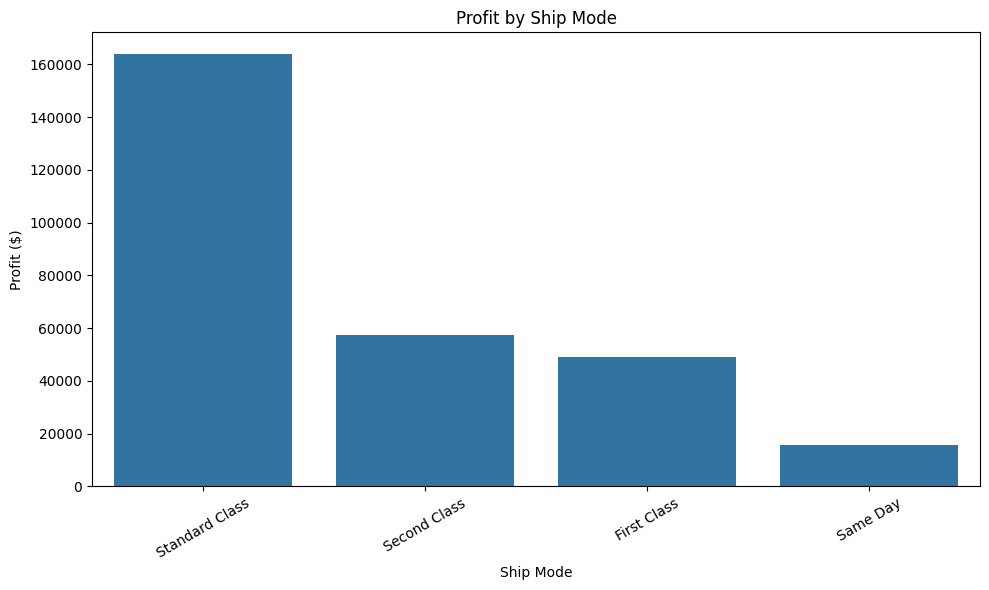

In [13]:
# ------------------------------------------------------------
# 14. PROFIT BY SHIP MODE
# ------------------------------------------------------------

ship_profit = df.groupby("Ship Mode")["Profit"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=ship_profit.index,
    y=ship_profit.values
)

plt.title("Profit by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Profit ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Top 10 States by Sales:
State
California      457576.2715
New York        310827.1510
Texas           170124.5418
Washington      138560.8100
Pennsylvania    116496.3620
Florida          89473.7080
Illinois         80162.5370
Ohio             77976.7640
Michigan         75879.6440
Virginia         70636.7200
Name: Sales, dtype: float64


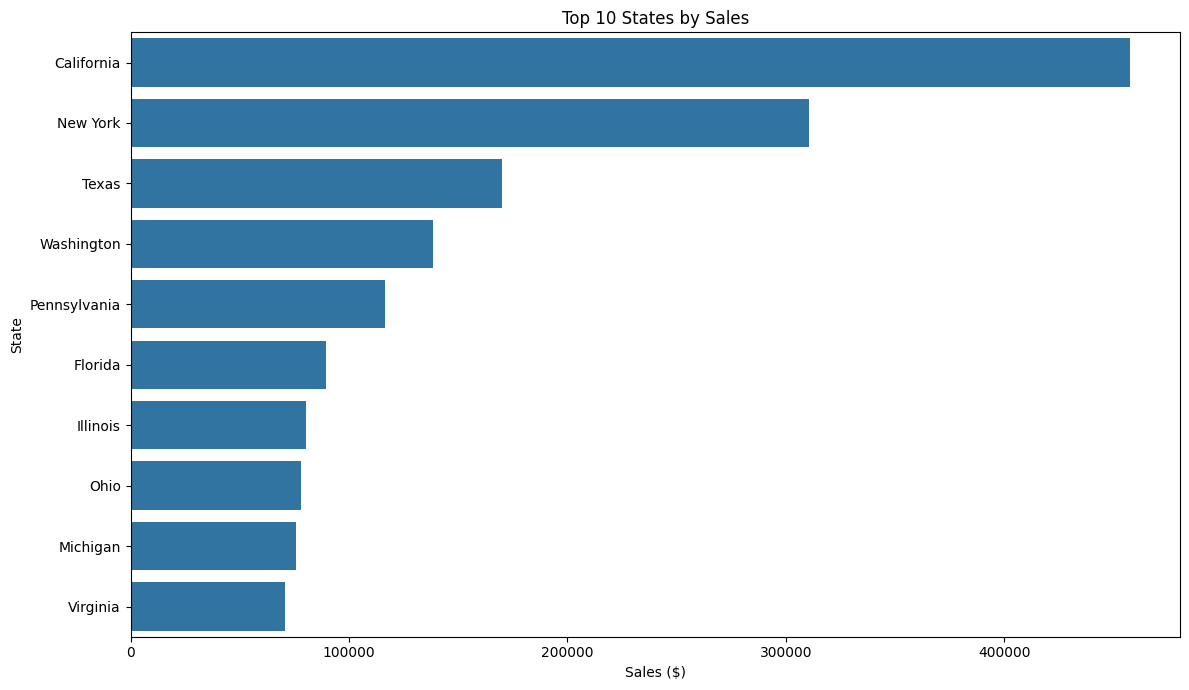

In [14]:
# ------------------------------------------------------------
# 15. TOP 10 STATES BY SALES
# ------------------------------------------------------------

state_sales = df.groupby("State")["Sales"].sum().sort_values(
    ascending=False
).head(10)

print("\nTop 10 States by Sales:")
print(state_sales)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=state_sales.values,
    y=state_sales.index
)

plt.title("Top 10 States by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

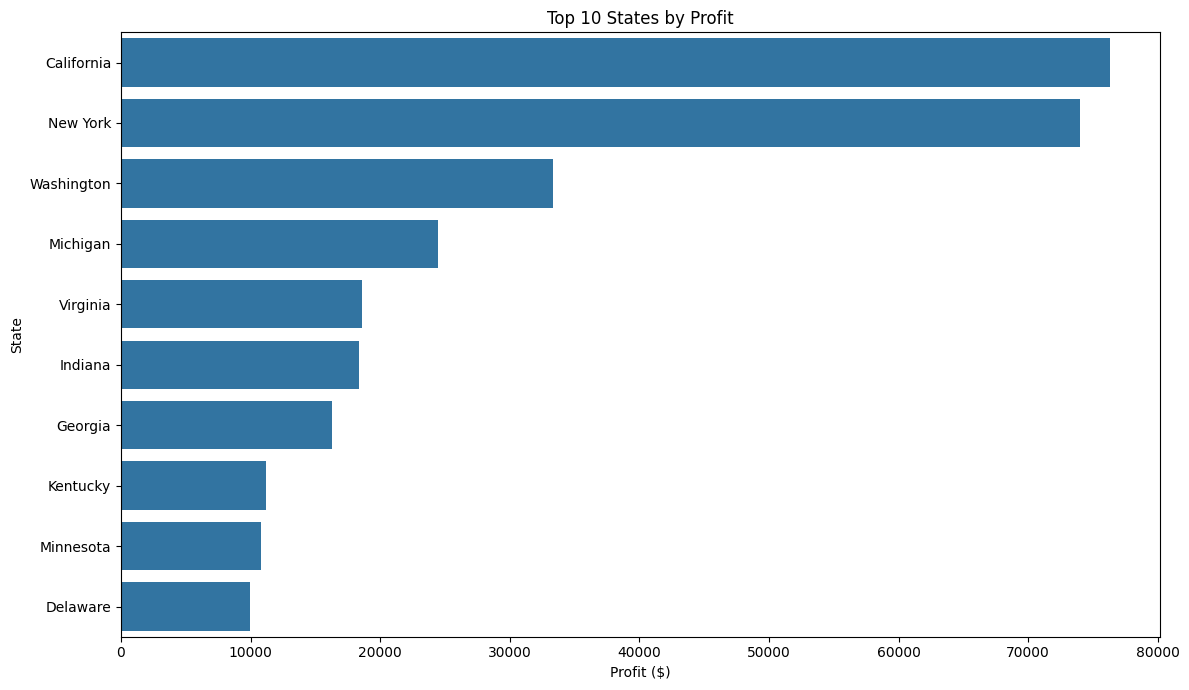

In [8]:
# ------------------------------------------------------------
# 16. TOP 10 STATES BY PROFIT
# ------------------------------------------------------------

state_profit = df.groupby("State")["Profit"].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=state_profit.values,
    y=state_profit.index
)

plt.title("Top 10 States by Profit")
plt.xlabel("Profit ($)")
plt.ylabel("State")
plt.tight_layout()
plt.show()


Top 10 Cities by Sales:
City
New York City    256319.0410
Los Angeles      175831.9010
Seattle          119460.2820
San Francisco    112577.1720
Philadelphia     109061.4610
Houston           64441.2564
Chicago           48535.9770
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: Sales, dtype: float64


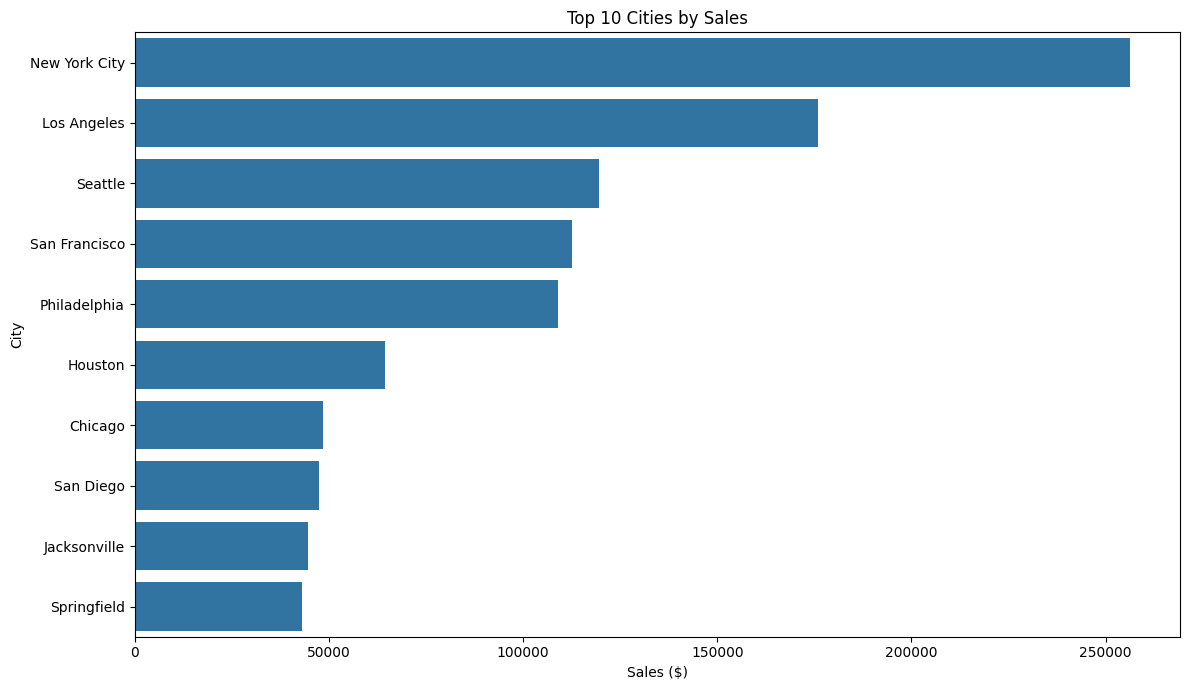

In [16]:
# ------------------------------------------------------------
# 17. TOP 10 CITIES BY SALES
# ------------------------------------------------------------

city_sales = df.groupby("City")["Sales"].sum().sort_values(
    ascending=False
).head(10)

print("\nTop 10 Cities by Sales:")
print(city_sales)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=city_sales.values,
    y=city_sales.index
)

plt.title("Top 10 Cities by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

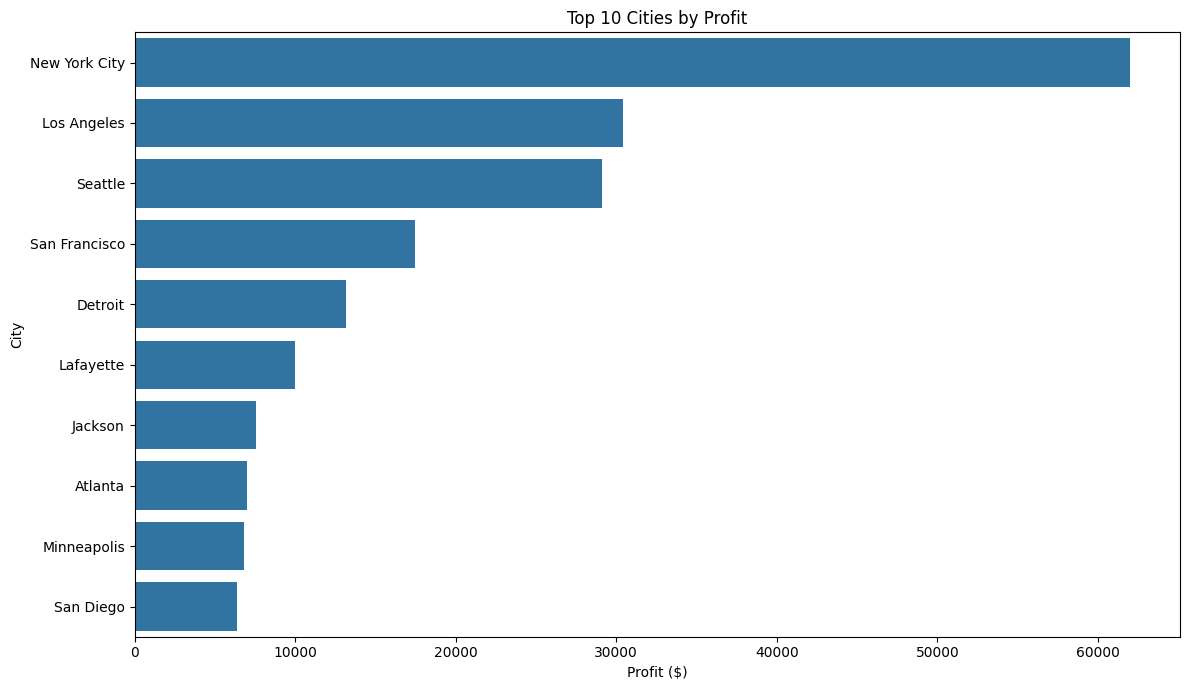

In [9]:
# ------------------------------------------------------------
# 18. TOP 10 CITIES BY PROFIT
# ------------------------------------------------------------

city_profit = df.groupby("City")["Profit"].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=city_profit.values,
    y=city_profit.index
)

plt.title("Top 10 Cities by Profit")
plt.xlabel("Profit ($)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

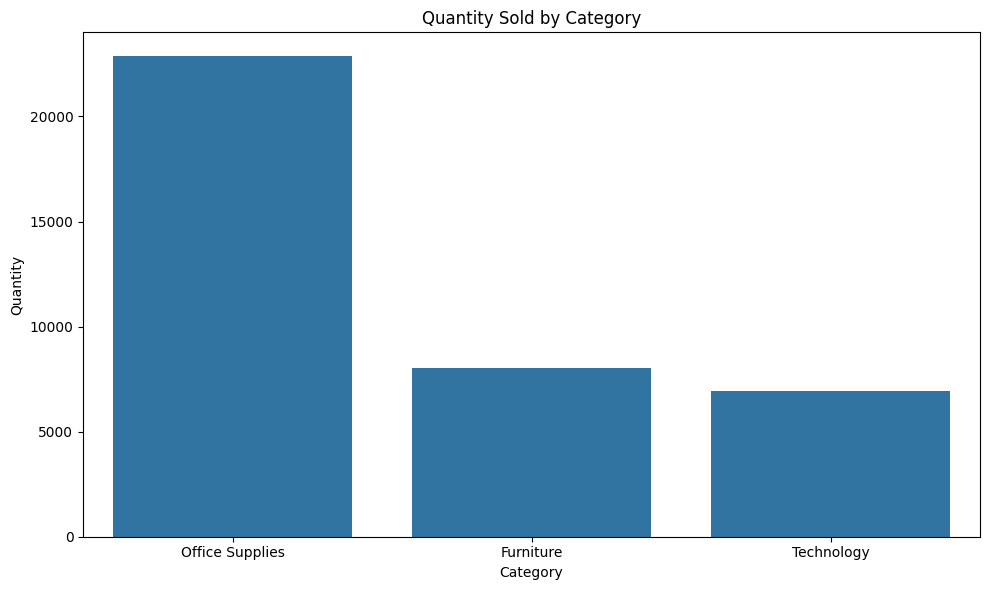

In [18]:
# ------------------------------------------------------------
# 19. QUANTITY BY CATEGORY
# ------------------------------------------------------------

category_quantity = df.groupby("Category")["Quantity"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_quantity.index,
    y=category_quantity.values
)

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Quantity")
plt.tight_layout()
plt.show()

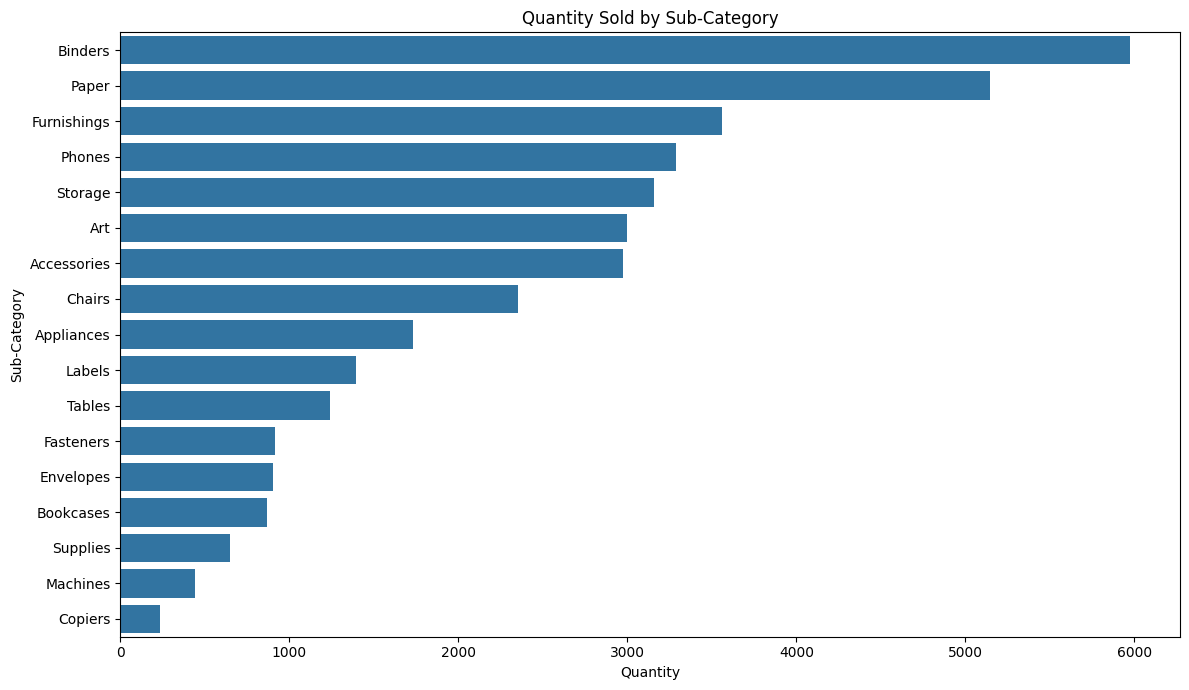

In [19]:
# ------------------------------------------------------------
# 20. QUANTITY BY SUB-CATEGORY
# ------------------------------------------------------------

subcategory_quantity = df.groupby("Sub-Category")["Quantity"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=subcategory_quantity.values,
    y=subcategory_quantity.index
)

plt.title("Quantity Sold by Sub-Category")
plt.xlabel("Quantity")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

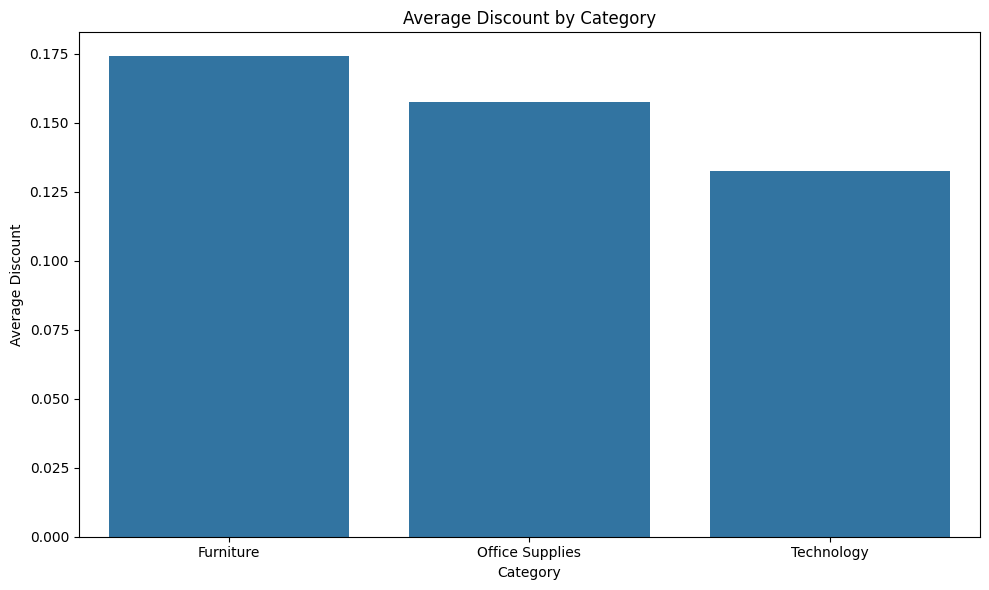

In [10]:
# ------------------------------------------------------------
# 21. AVERAGE DISCOUNT BY CATEGORY
# ------------------------------------------------------------

category_discount = df.groupby("Category")["Discount"].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_discount.index,
    y=category_discount.values
)

plt.title("Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount")
plt.tight_layout()
plt.show()

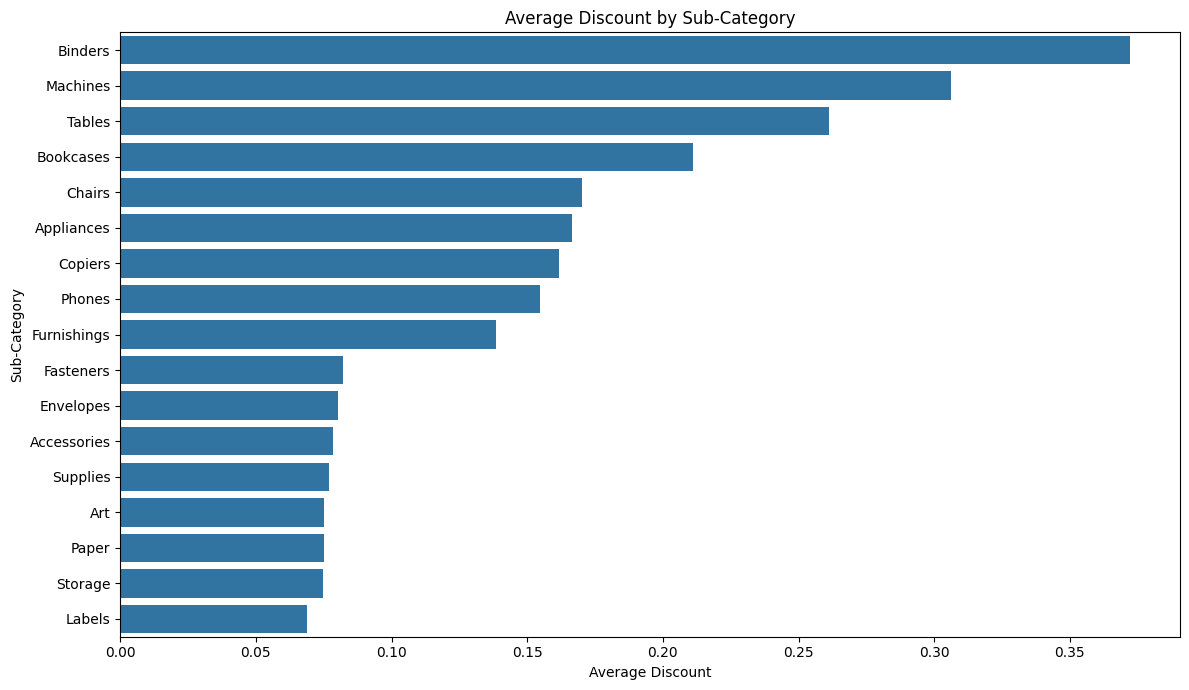

In [21]:
# ------------------------------------------------------------
# 22. AVERAGE DISCOUNT BY SUB-CATEGORY
# ------------------------------------------------------------

subcategory_discount = df.groupby("Sub-Category")["Discount"].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=subcategory_discount.values,
    y=subcategory_discount.index
)

plt.title("Average Discount by Sub-Category")
plt.xlabel("Average Discount")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

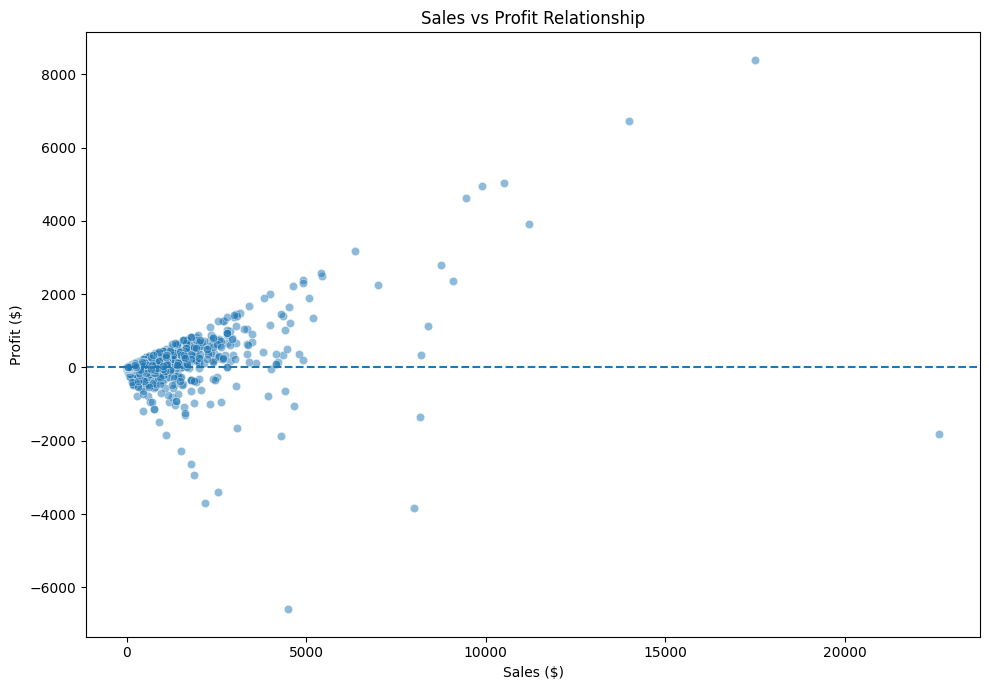

In [11]:
# ------------------------------------------------------------
# 23. SALES VS PROFIT
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    alpha=0.5
)

plt.axhline(0, linestyle="--")

plt.title("Sales vs Profit Relationship")
plt.xlabel("Sales ($)")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()

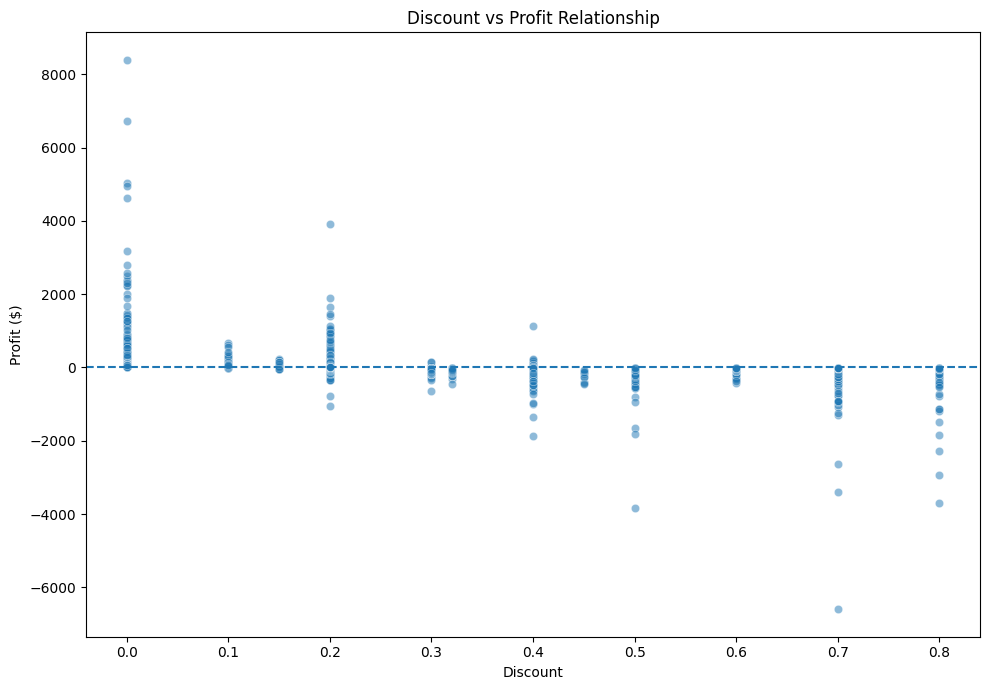

In [23]:
# ------------------------------------------------------------
# 24. DISCOUNT VS PROFIT
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.5
)

plt.axhline(0, linestyle="--")

plt.title("Discount vs Profit Relationship")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()

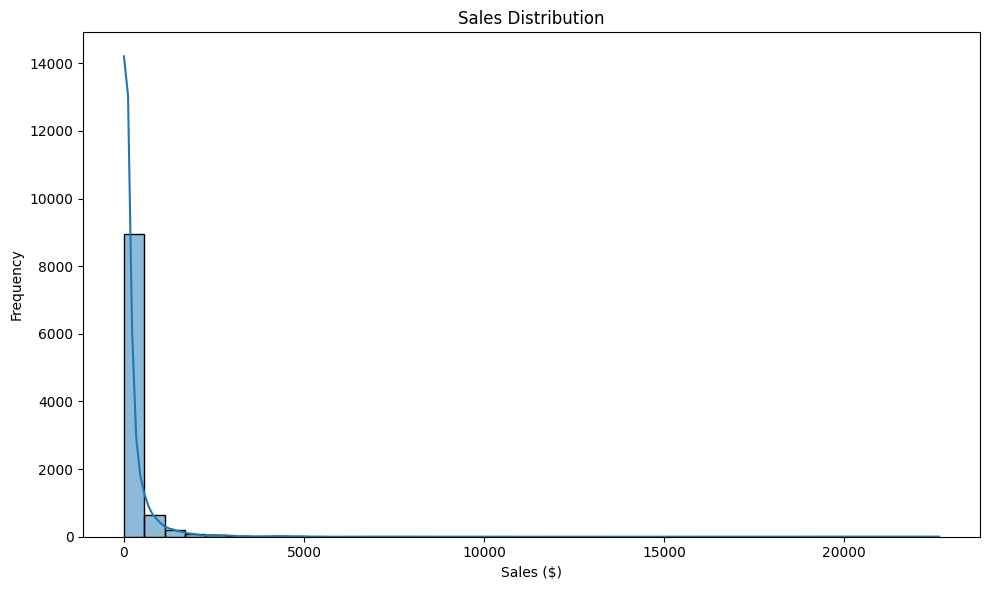

In [12]:
# ------------------------------------------------------------
# 25. SALES DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Sales"],
    bins=40,
    kde=True
)

plt.title("Sales Distribution")
plt.xlabel("Sales ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

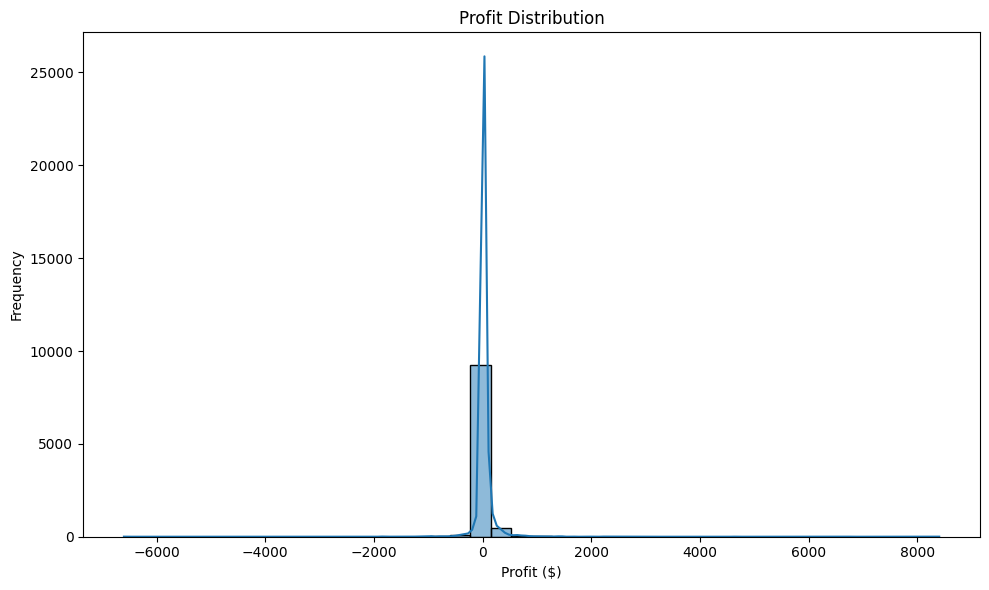

In [25]:
# ------------------------------------------------------------
# 26. PROFIT DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Profit"],
    bins=40,
    kde=True
)

plt.title("Profit Distribution")
plt.xlabel("Profit ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

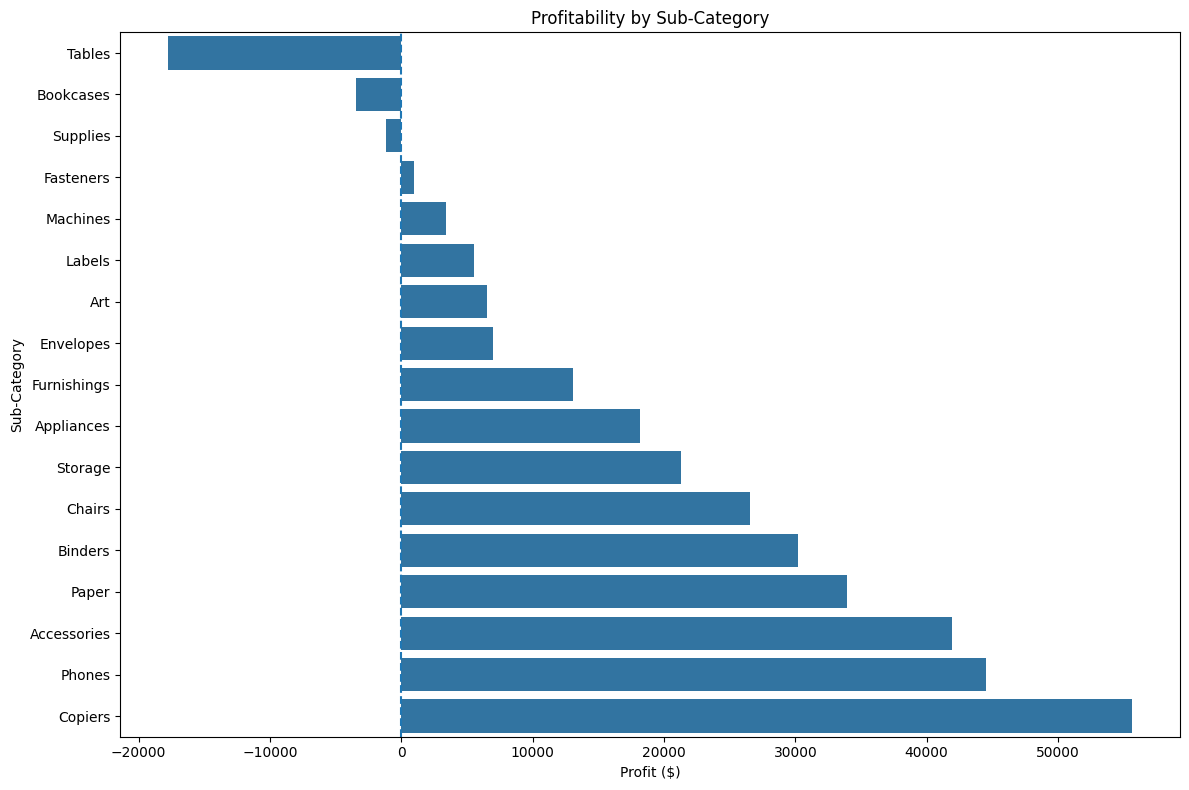

In [13]:
# ------------------------------------------------------------
# 29. PROFITABILITY BY SUB-CATEGORY
# ------------------------------------------------------------

profit_analysis = df.groupby("Sub-Category")["Profit"].sum().sort_values()

plt.figure(figsize=(12, 8))

sns.barplot(
    x=profit_analysis.values,
    y=profit_analysis.index
)

plt.axvline(0, linestyle="--")

plt.title("Profitability by Sub-Category")
plt.xlabel("Profit ($)")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

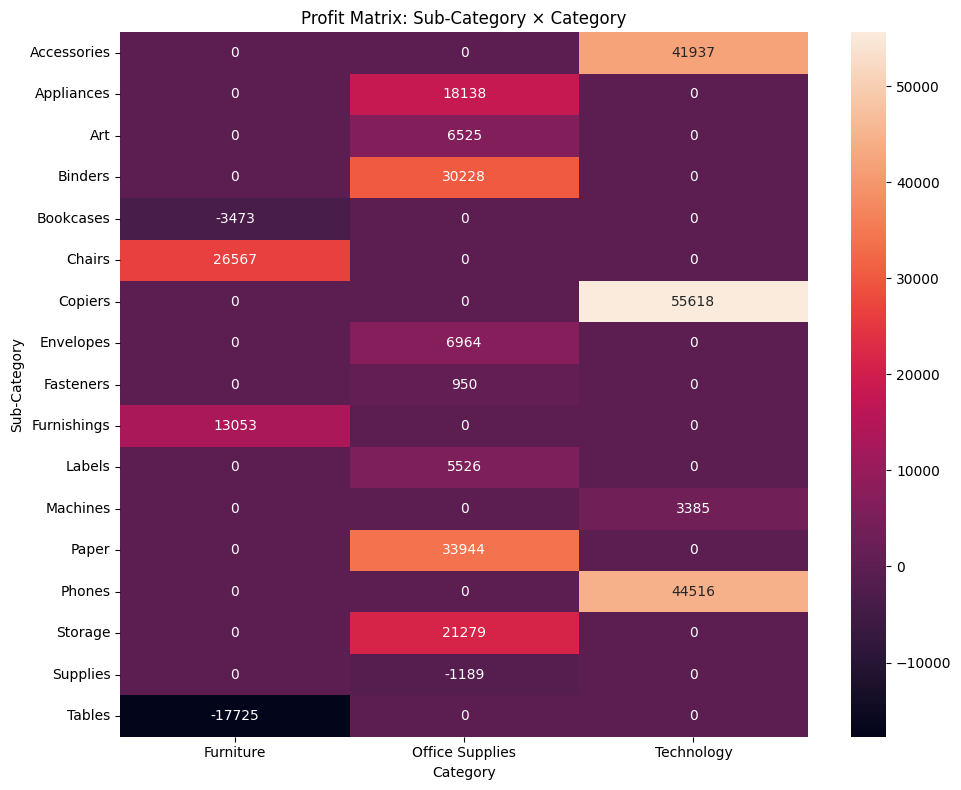

In [27]:
# ------------------------------------------------------------
# 30. PROFIT MATRIX
# ------------------------------------------------------------

profit_matrix = pd.pivot_table(
    df,
    index="Sub-Category",
    columns="Category",
    values="Profit",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    profit_matrix,
    annot=True,
    fmt=".0f"
)

plt.title("Profit Matrix: Sub-Category × Category")
plt.xlabel("Category")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

In [14]:
# ------------------------------------------------------------
# 31. MONTHLY SALES TREND
# ------------------------------------------------------------

# Check whether a date column exists

possible_date_columns = [
    "Order Date",
    "Order_Date",
    "Sales Date",
    "Sales_Date",
    "Date"
]

date_column = None

for col in possible_date_columns:
    if col in df.columns:
        date_column = col
        break

if date_column is not None:

    print("\nDate column found:", date_column)

    df[date_column] = pd.to_datetime(
        df[date_column],
        errors="coerce"
    )

    # Remove invalid dates
    df_date = df.dropna(subset=[date_column]).copy()

    # Create Month column
    df_date["Month"] = df_date[date_column].dt.to_period("M")

    monthly_sales = (
        df_date.groupby("Month")["Sales"]
        .sum()
        .reset_index()
    )

    monthly_sales["Month"] = monthly_sales["Month"].astype(str)

    print("\nMonthly Sales:")
    print(monthly_sales)

    # Monthly Sales Trend
    plt.figure(figsize=(14, 7))

    plt.plot(
        monthly_sales["Month"],
        monthly_sales["Sales"],
        marker="o"
    )

    plt.title("Monthly Sales Trend")
    plt.xlabel("Month")
    plt.ylabel("Sales ($)")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [34]:
# ------------------------------------------------------------
# 32. TOP 10 PROFITABLE SUB-CATEGORIES
# ------------------------------------------------------------

top_profit_subcategories = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Profitable Sub-Categories:")
print(top_profit_subcategories)


Top 10 Profitable Sub-Categories:
Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          33944.2395
Binders        30228.0003
Chairs         26567.1278
Storage        21278.8264
Appliances     18138.0054
Furnishings    13052.7230
Envelopes       6964.1767
Name: Profit, dtype: float64


In [20]:
# ------------------------------------------------------------
# 33. TOP 10 LOSS-MAKING SUB-CATEGORIES
# ------------------------------------------------------------

loss_subcategories = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values()
    .head(10)
)

print("\nTop 10 Loss-Making Sub-Categories:")
print(loss_subcategories)


Top 10 Loss-Making Sub-Categories:
Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5526.3820
Art             6524.6118
Envelopes       6964.1767
Furnishings    13052.7230
Appliances     18138.0054
Name: Profit, dtype: float64


# ============================================================
# TOP 10 SUB-CATEGORIES ANALYSIS - 20 GRAPH-BASED ANALYSIS
# Sample Superstore Dataset
# ============================================================

# Top 10 Products

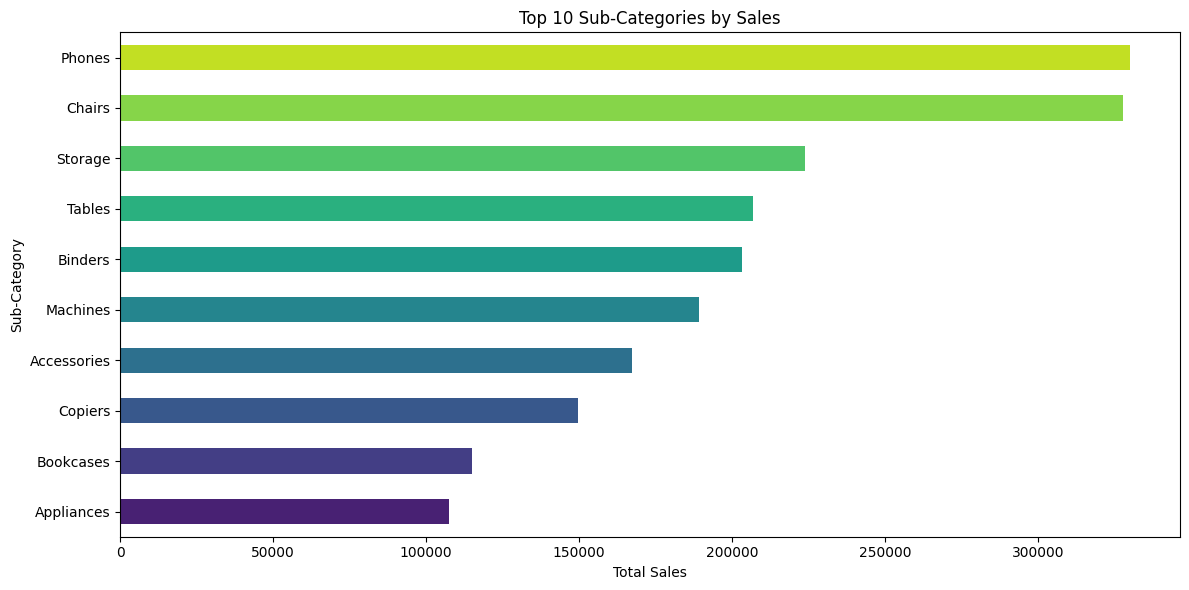

In [21]:
# ============================================================
# 1. TOP 10 SUB-CATEGORIES BY SALES
# ============================================================

top_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_sales.sort_values().plot(
    kind="barh",
    color=sns.color_palette("viridis", 10)
)
plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

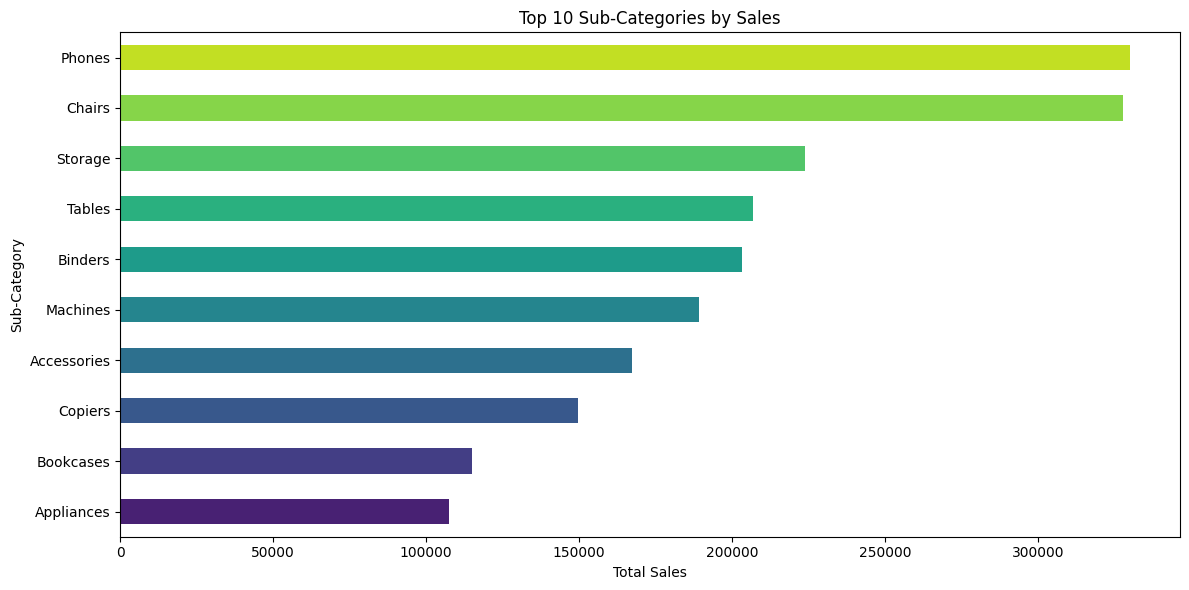

In [23]:
# ============================================================
# 1. TOP 10 SUB-CATEGORIES BY SALES
# ============================================================

top_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_sales.sort_values().plot(
    kind="barh",
    color=sns.color_palette("viridis", 10)
)
plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

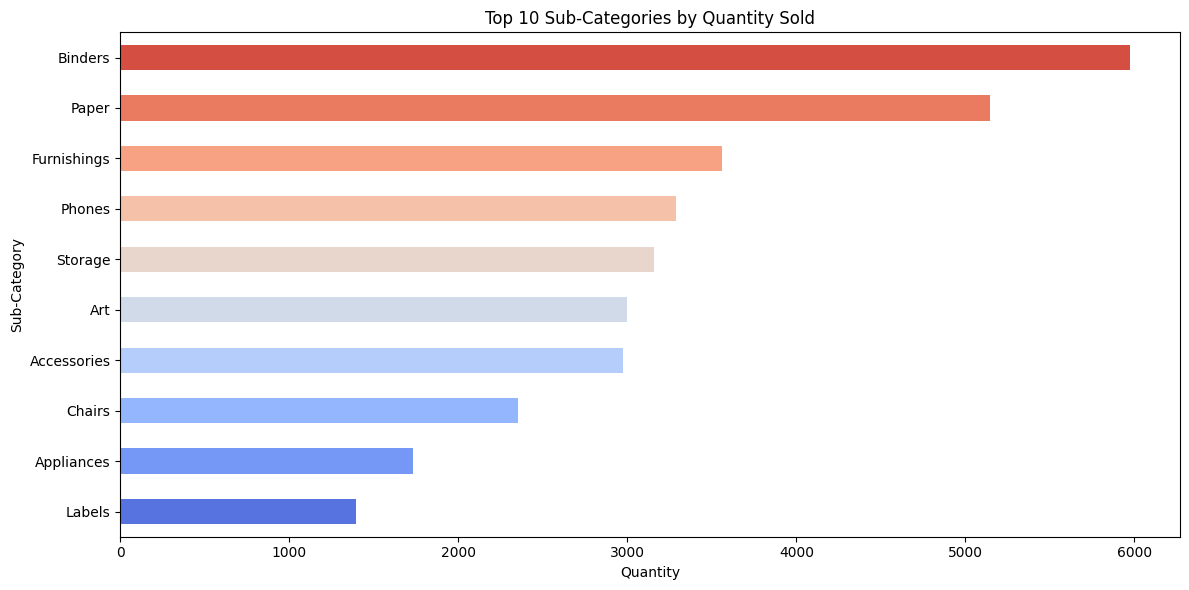

In [24]:
# ============================================================
# 3. TOP 10 SUB-CATEGORIES BY QUANTITY
# ============================================================

top_quantity = (
    df.groupby("Sub-Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_quantity.sort_values().plot(
    kind="barh",
    color=sns.color_palette("coolwarm", 10)
)
plt.title("Top 10 Sub-Categories by Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

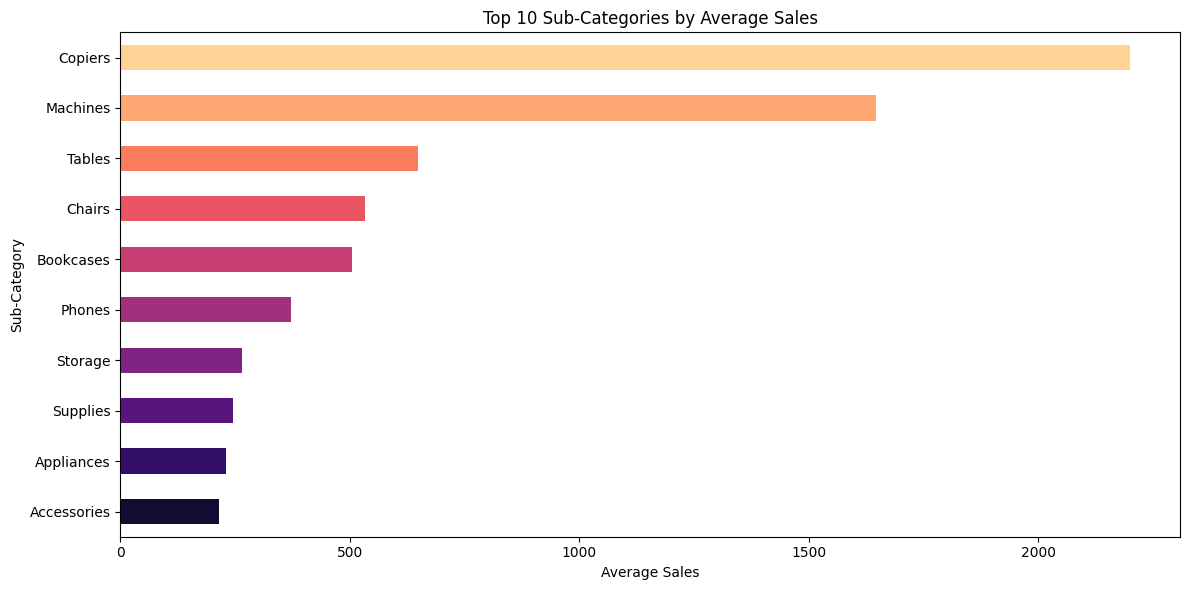

In [25]:


# ============================================================
# 4. TOP 10 BY AVERAGE SALES
# ============================================================

avg_sales = (
    df.groupby("Sub-Category")["Sales"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
avg_sales.sort_values().plot(
    kind="barh",
    color=sns.color_palette("magma", 10)
)
plt.title("Top 10 Sub-Categories by Average Sales")
plt.xlabel("Average Sales")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()


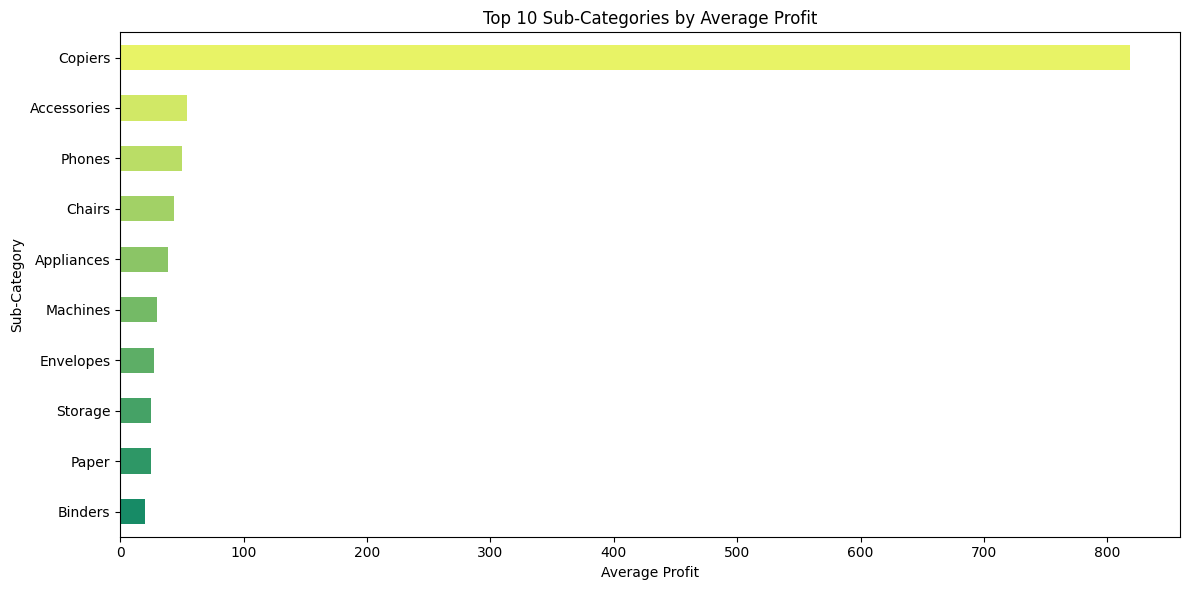

In [26]:

# ============================================================
# 5. TOP 10 BY AVERAGE PROFIT
# ============================================================

avg_profit = (
    df.groupby("Sub-Category")["Profit"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
avg_profit.sort_values().plot(
    kind="barh",
    color=sns.color_palette("summer", 10)
)
plt.title("Top 10 Sub-Categories by Average Profit")
plt.xlabel("Average Profit")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

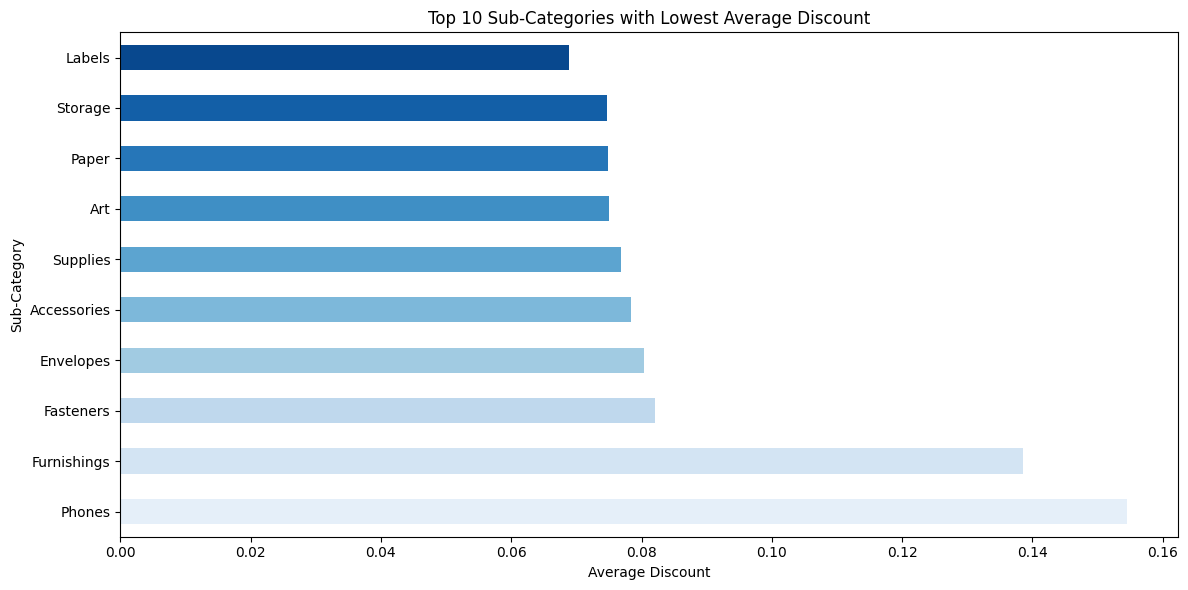

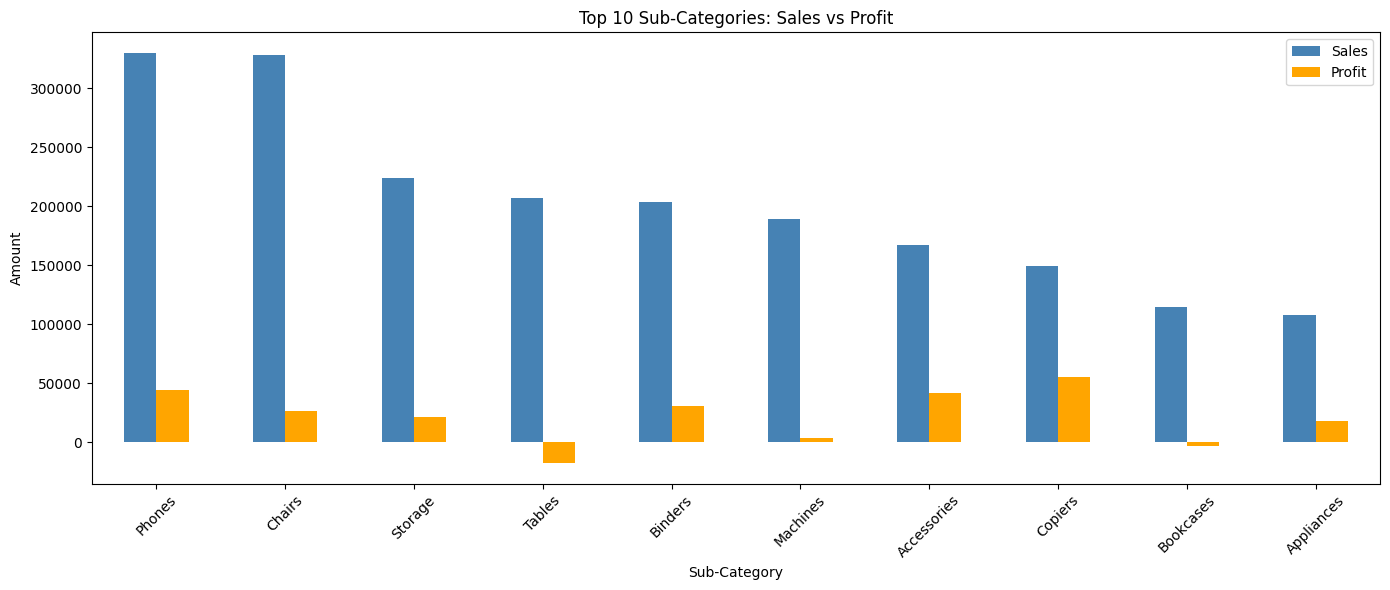

In [27]:
# ============================================================
# 6. TOP 10 BY LOWEST DISCOUNT
# ============================================================

low_discount = (
    df.groupby("Sub-Category")["Discount"]
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(12, 6))
low_discount.sort_values(ascending=False).plot(
    kind="barh",
    color=sns.color_palette("Blues", 10)
)
plt.title("Top 10 Sub-Categories with Lowest Average Discount")
plt.xlabel("Average Discount")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()


# ============================================================
# 7. SALES VS PROFIT - TOP 10
# ============================================================

comparison = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
    .head(10)
)

comparison.plot(
    kind="bar",
    figsize=(14, 6),
    color=["steelblue", "orange"]
)

plt.title("Top 10 Sub-Categories: Sales vs Profit")
plt.xlabel("Sub-Category")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

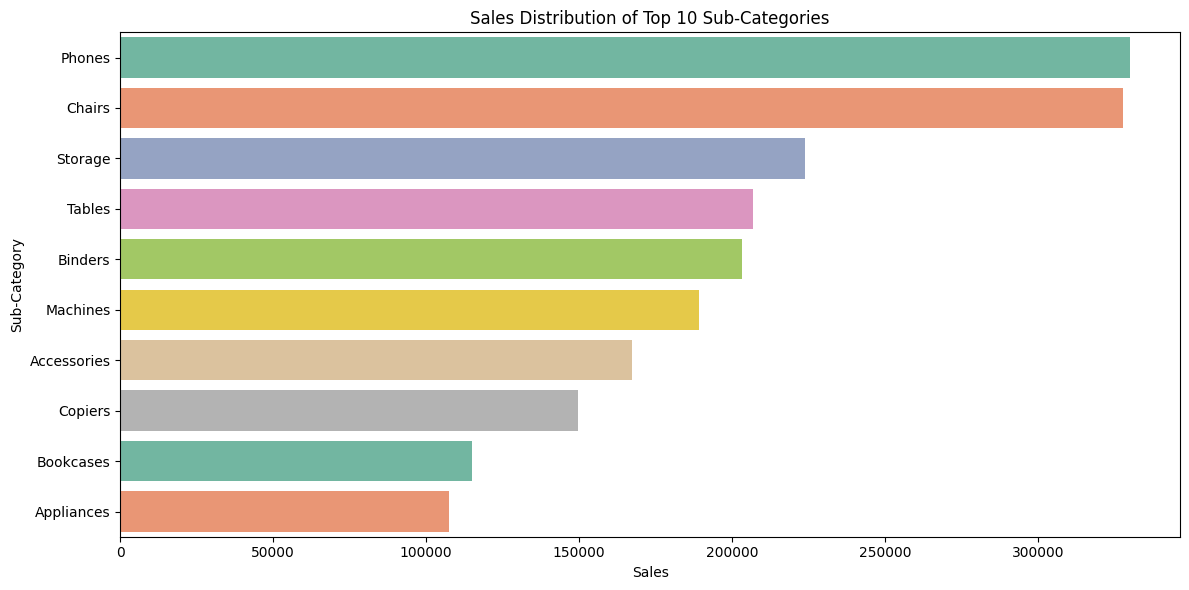

In [29]:
# ============================================================
# 8. SALES DISTRIBUTION - TOP 10
# ============================================================

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_sales.values,
    y=top_sales.index,
    hue=top_sales.index,
    palette="Set2",
    legend=False
)
plt.title("Sales Distribution of Top 10 Sub-Categories")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

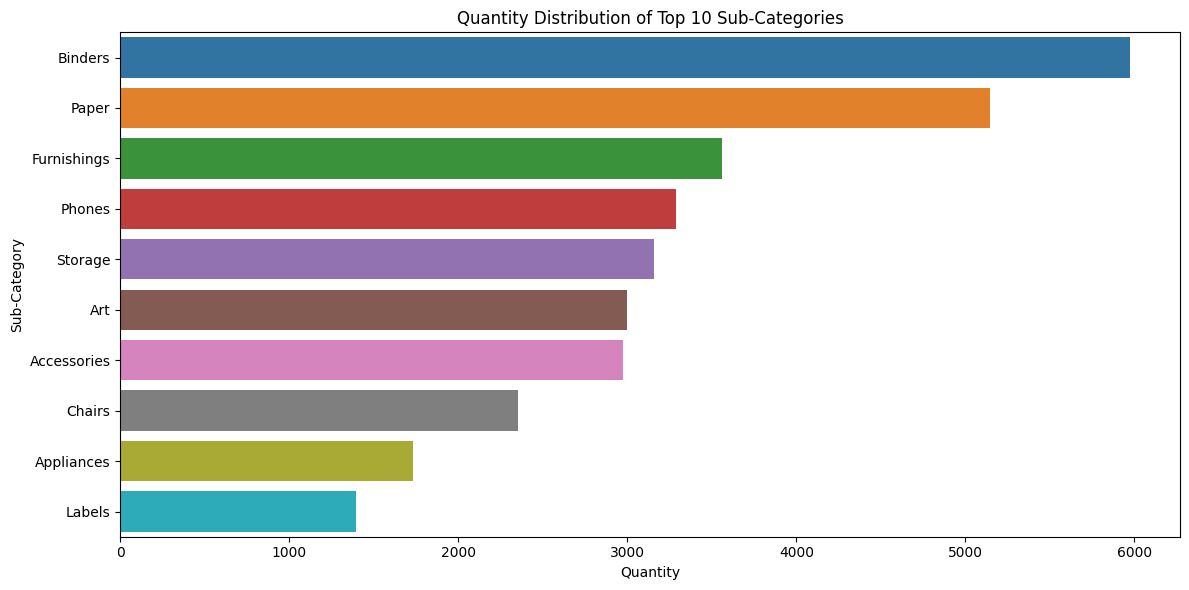

In [31]:
# ============================================================
# 10. QUANTITY DISTRIBUTION - TOP 10
# ============================================================

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_quantity.values,
    y=top_quantity.index,
    hue=top_quantity.index,
    palette="tab10",
    legend=False
)
plt.title("Quantity Distribution of Top 10 Sub-Categories")
plt.xlabel("Quantity")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

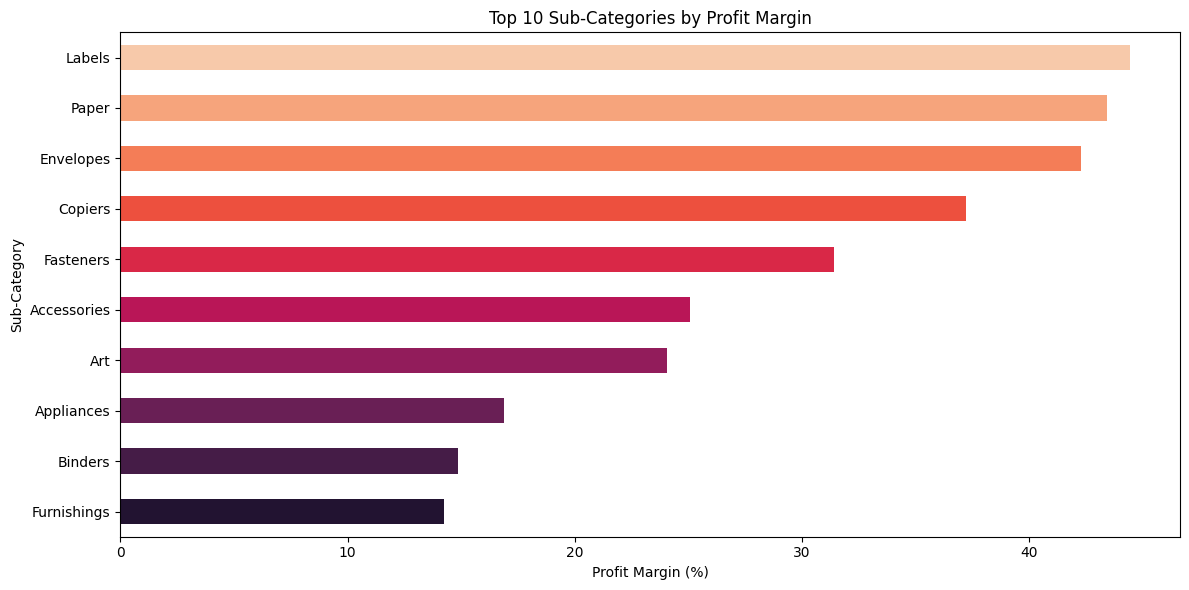

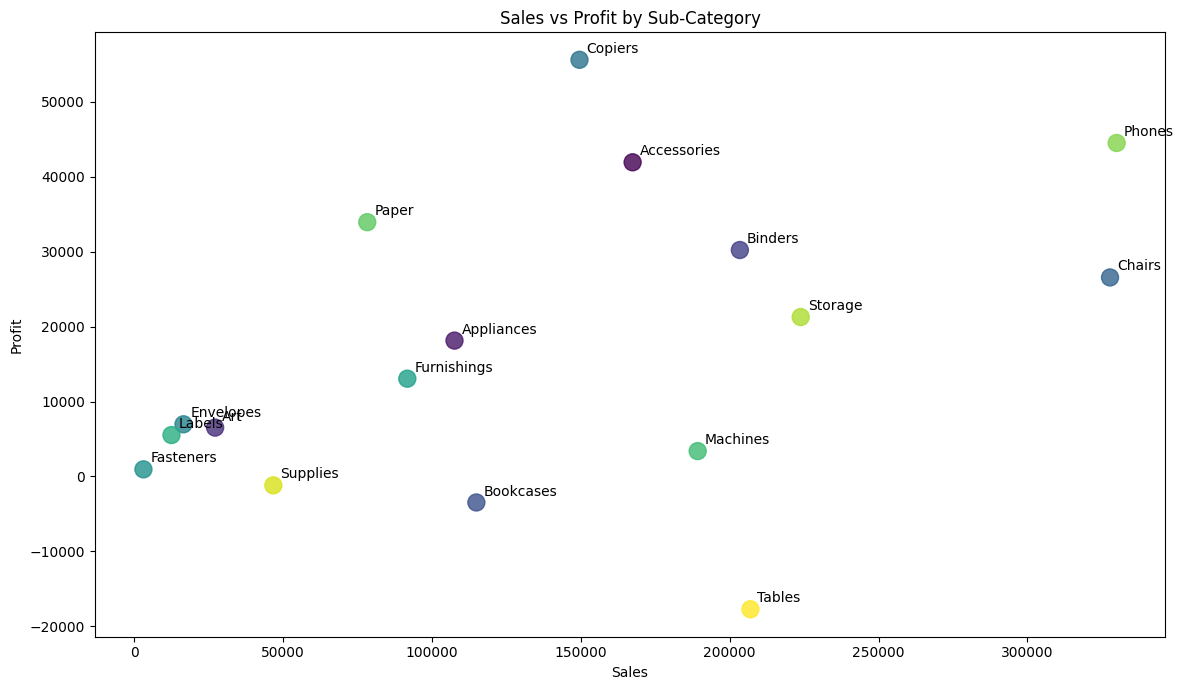

In [32]:
# ============================================================
# 11. PROFIT MARGIN - TOP 10
# ============================================================

margin = (
    df.groupby("Sub-Category")
    .agg(Sales=("Sales", "sum"),
         Profit=("Profit", "sum"))
)

margin["Profit Margin"] = (
    margin["Profit"] / margin["Sales"] * 100
)

top_margin = margin.sort_values(
    "Profit Margin",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))
top_margin["Profit Margin"].sort_values().plot(
    kind="barh",
    color=sns.color_palette("rocket", 10)
)
plt.title("Top 10 Sub-Categories by Profit Margin")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()


# ============================================================
# 12. SALES VS PROFIT SCATTER
# ============================================================

plt.figure(figsize=(12, 7))

scatter_data = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
)

plt.scatter(
    scatter_data["Sales"],
    scatter_data["Profit"],
    s=150,
    c=np.arange(len(scatter_data)),
    cmap="viridis",
    alpha=0.8
)

for name, row in scatter_data.iterrows():
    plt.annotate(
        name,
        (row["Sales"], row["Profit"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Sales vs Profit by Sub-Category")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


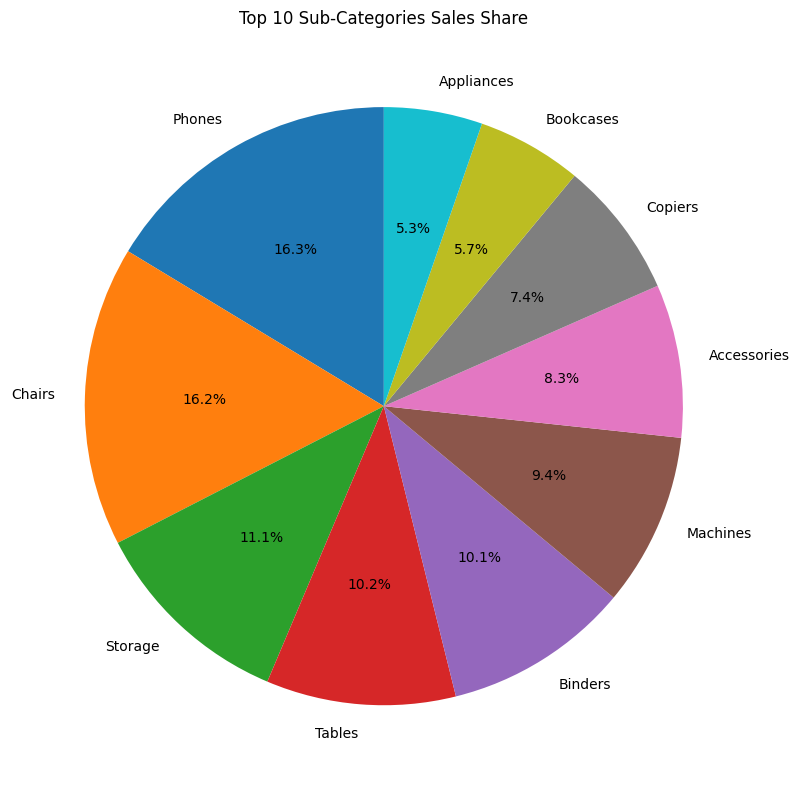

In [34]:


# ============================================================
# 13. TOP 10 SALES SHARE
# ============================================================

sales_share = (
    top_sales / df["Sales"].sum() * 100
)

plt.figure(figsize=(10, 8))
plt.pie(
    sales_share.values,
    labels=sales_share.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("tab10", 10)
)
plt.title("Top 10 Sub-Categories Sales Share")
plt.tight_layout()
plt.show()




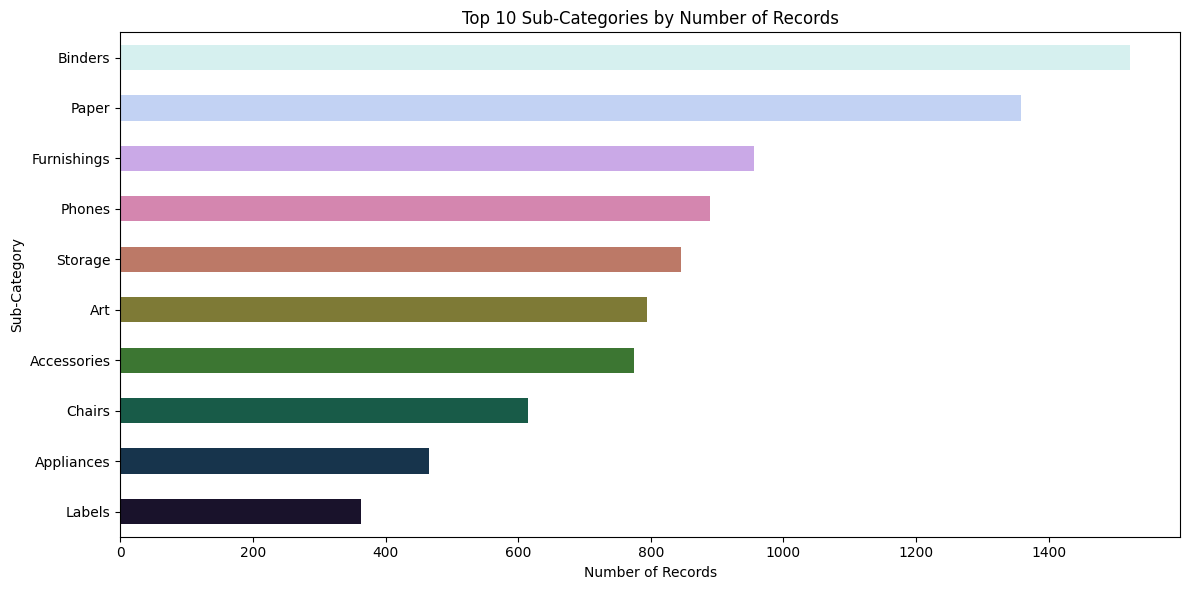

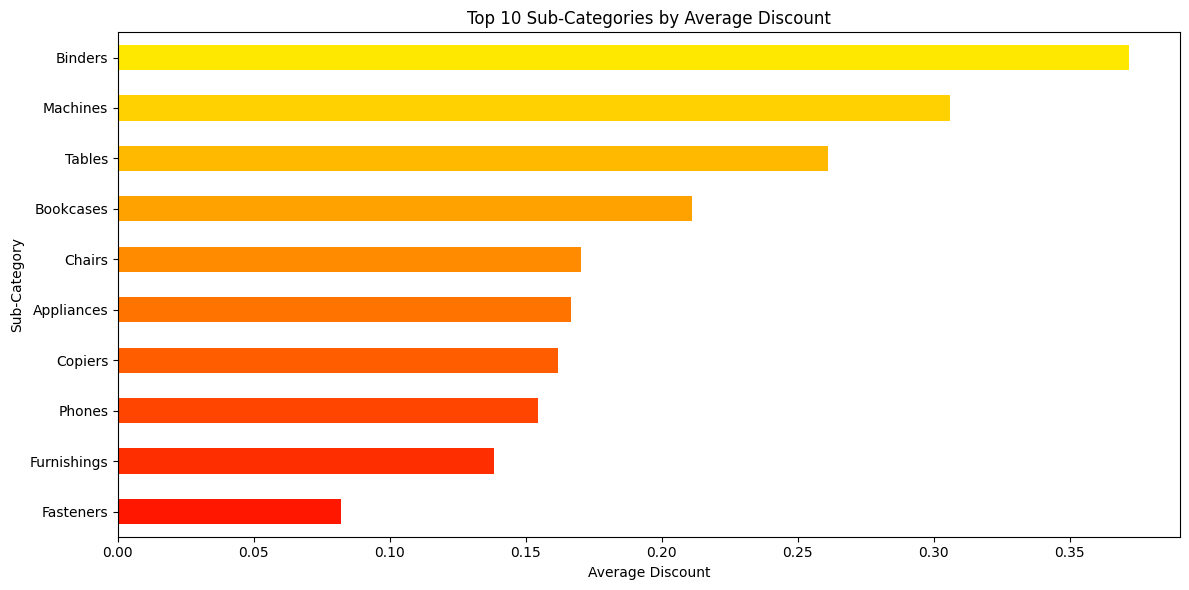

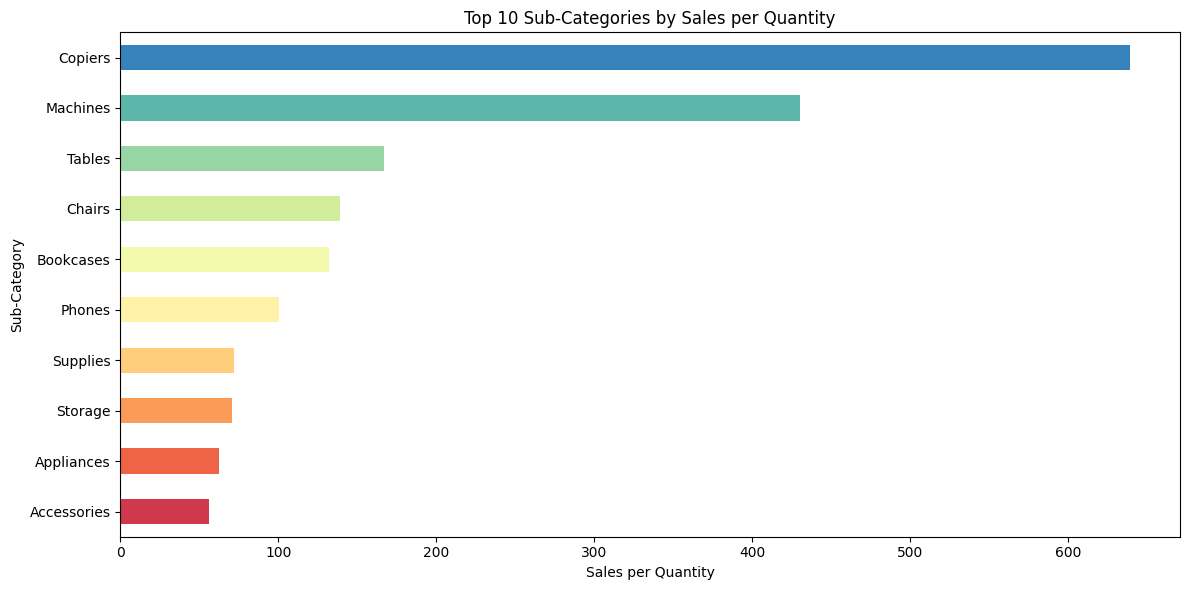

In [35]:

# ============================================================
# 15. TOP 10 SUB-CATEGORIES BY RECORD COUNT
# ============================================================

record_count = (
    df["Sub-Category"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 6))
record_count.sort_values().plot(
    kind="barh",
    color=sns.color_palette("cubehelix", 10)
)
plt.title("Top 10 Sub-Categories by Number of Records")
plt.xlabel("Number of Records")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()


# ============================================================
# 16. TOP 10 SUB-CATEGORIES BY DISCOUNT
# ============================================================

high_discount = (
    df.groupby("Sub-Category")["Discount"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
high_discount.sort_values().plot(
    kind="barh",
    color=sns.color_palette("autumn", 10)
)
plt.title("Top 10 Sub-Categories by Average Discount")
plt.xlabel("Average Discount")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()


# ============================================================
# 17. SALES PER QUANTITY
# ============================================================

sales_quantity = (
    df.groupby("Sub-Category")
    .agg(
        Sales=("Sales", "sum"),
        Quantity=("Quantity", "sum")
    )
)

sales_quantity["Sales per Quantity"] = (
    sales_quantity["Sales"] /
    sales_quantity["Quantity"]
)

top_sales_quantity = (
    sales_quantity["Sales per Quantity"]
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_sales_quantity.sort_values().plot(
    kind="barh",
    color=sns.color_palette("Spectral", 10)
)
plt.title("Top 10 Sub-Categories by Sales per Quantity")
plt.xlabel("Sales per Quantity")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

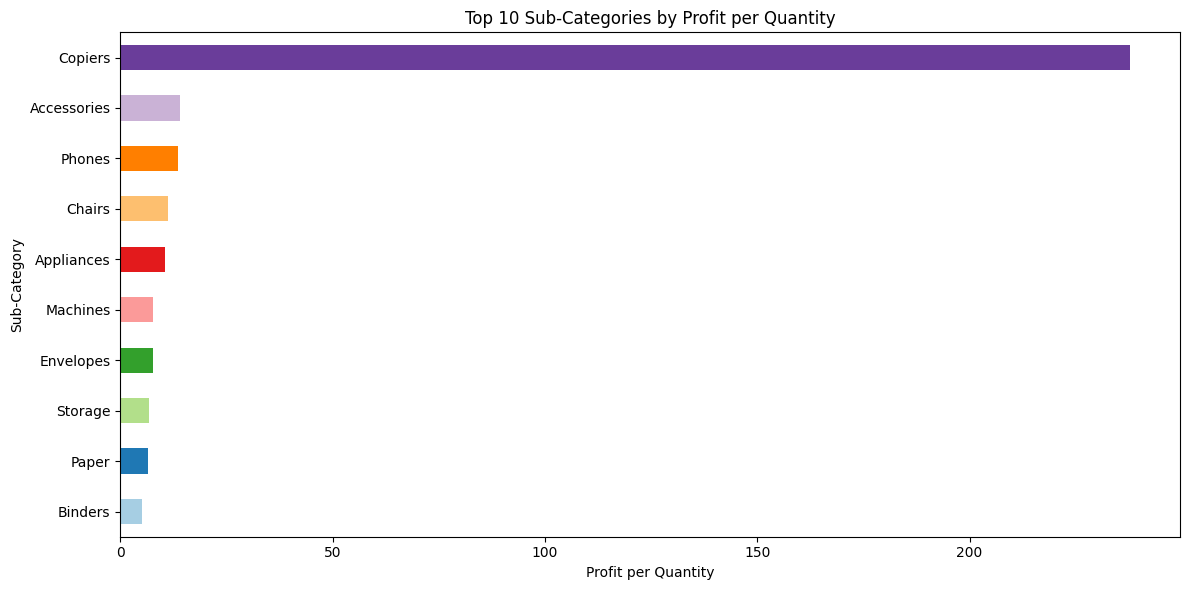

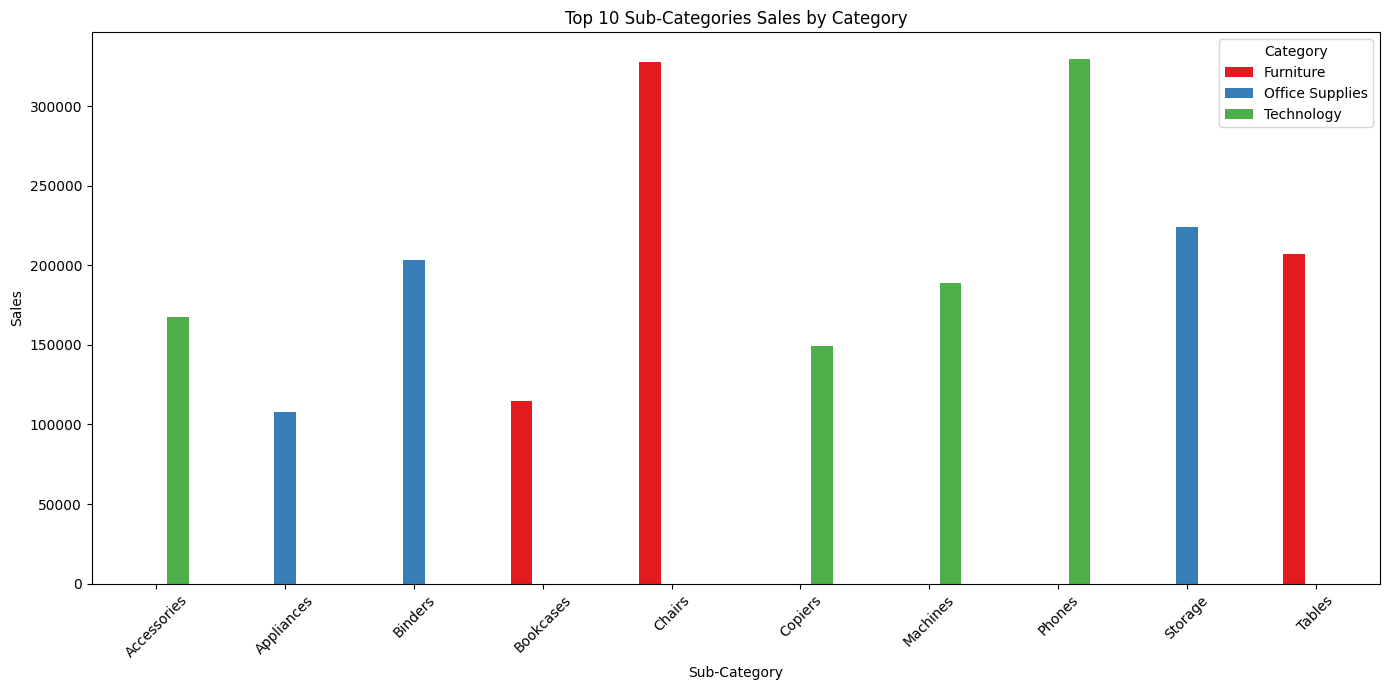

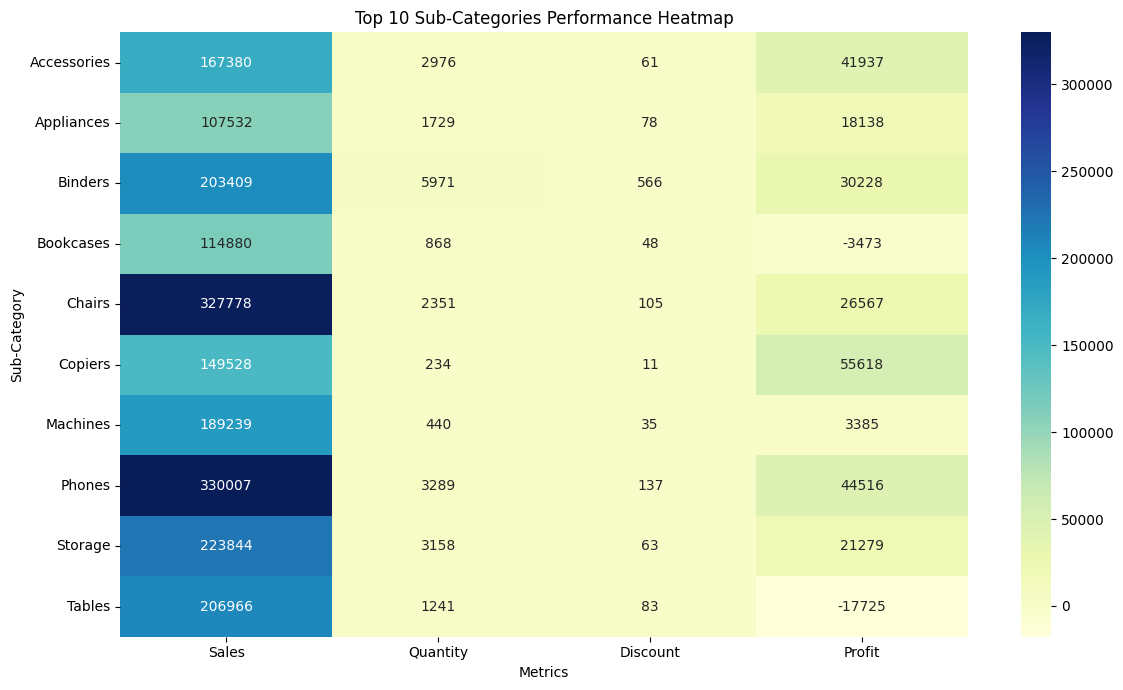

In [38]:
# ============================================================
# 18. PROFIT PER QUANTITY
# ============================================================

profit_quantity = (
    df.groupby("Sub-Category")
    .agg(
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
)

profit_quantity["Profit per Quantity"] = (
    profit_quantity["Profit"] /
    profit_quantity["Quantity"]
)

top_profit_quantity = (
    profit_quantity["Profit per Quantity"]
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_profit_quantity.sort_values().plot(
    kind="barh",
    color=sns.color_palette("Paired", 10)
)
plt.title("Top 10 Sub-Categories by Profit per Quantity")
plt.xlabel("Profit per Quantity")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()


# ============================================================
# 19. SALES BY CATEGORY FOR TOP 10 SUB-CATEGORIES
# ============================================================

top10_names = top_sales.index

category_sales = (
    df[df["Sub-Category"].isin(top10_names)]
    .groupby(["Sub-Category", "Category"])["Sales"]
    .sum()
    .unstack(fill_value=0)
)

category_sales.plot(
    kind="bar",
    figsize=(14, 7),
    color=sns.color_palette("Set1", len(category_sales.columns))
)

plt.title("Top 10 Sub-Categories Sales by Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 20. PROFITABILITY HEATMAP - TOP 10
# ============================================================

heatmap_data = (
    df[df["Sub-Category"].isin(top10_names)]
    .groupby("Sub-Category")[["Sales", "Quantity", "Discount", "Profit"]]
    .sum()
)

plt.figure(figsize=(12, 7))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Top 10 Sub-Categories Performance Heatmap")
plt.xlabel("Metrics")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()



## Conclusion

The Top 10 Sub-Categories analysis provides a clear view of sales, quantity, profit, discount, and profitability across the Superstore dataset.

The analysis shows that **high sales do not always result in high profit**. Some sub-categories generate strong sales but comparatively lower profits, while others achieve better profitability with lower sales. The comparison of sales and profit therefore provides more useful business information than looking at sales alone.

The visualizations also help identify important differences in quantity sold, average sales, average profit, discounts, profit margins, and sales efficiency. Overall, the analysis demonstrates how **data visualization can be used to identify business trends, compare product performance, and support data-driven decision-making**.
